In [ ]:
# ============================================================
# SETUP: Configure paths and imports for reproducibility
# ============================================================
import os
import sys

# Auto-detect repository root by walking up directories
_current = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_current, 'dcpbst_package')):
        break
    _current = os.path.dirname(_current)
else:
    _current = os.getcwd()

REPO_ROOT = _current
DATA_DIR = os.path.join(REPO_ROOT, 'data')
FIGURES_DIR = os.path.join(REPO_ROOT, 'figures')
RESULTS_DIR = os.path.join(REPO_ROOT, 'saved_results')
CONFIGS_DIR = os.path.join(REPO_ROOT, 'configs')

# Change to repo root so relative paths work
os.chdir(REPO_ROOT)

# Add dcpbst_package to import path
sys.path.insert(0, os.path.join(REPO_ROOT, 'dcpbst_package'))
print(f'Repo root: {REPO_ROOT}')
print(f'Data dir: {DATA_DIR}')

# Set random seeds for reproducibility
import numpy as np
import torch
import random
seed = 100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    device = 'cuda'
else:
    device = 'cpu'
print(f'Device: {device}')


CUDA is available. GPU: NVIDIA GeForce RTX 4060 Ti


/root/miniconda3/envs/miso/lib/python3.7/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loaded data: (3798, 36601)


/root/miniconda3/envs/miso/lib/python3.7/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


scrna shape: (3798, 3000)


/root/miniconda3/envs/miso/lib/python3.7/site-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and may be removed in the future, "
/root/miniconda3/envs/miso/lib/python3.7/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


cut_img_BRCA/cut_img_BRCA.npy
cutting image  finished!
cut_img_BRCA/cut_img_BRCA.npy
the image feature has been extracted!
image_emb shape: (3798, 1000)
20
发现 'Ground Truth'，准备用于监督学习的标签...
正在构建空间、基因和图像特征的邻接矩阵...
所有邻接矩阵构建完成。
Classifier created: Input dim=256, Output dim=20
Initializing Modal Robustness Diagnoser...
Initial weights of encoders have been saved.


Training Miso Model:   0%|          | 0/900 [00:00<?, ?it/s]


Epoch 10/900 | Total Loss: 533.3699 | Recon: 1.9329 | KL: 963.3311 | InfoNCE: 8.3623 | DGI: 34.5570|Proxy: 3.0817|Classfity: 37.9921

Epoch 20/900 | Total Loss: 196.8928 | Recon: 1.8634 | KL: 835.2079 | InfoNCE: 8.4234 | DGI: 34.5388|Proxy: 3.0550|Classfity: 5.6849

Epoch 30/900 | Total Loss: 139.6911 | Recon: 1.8253 | KL: 655.1204 | InfoNCE: 8.3270 | DGI: 34.5388|Proxy: 3.0358|Classfity: 1.8384

--- Running Diagnose & Re-learn at epoch 30 ---
Diagnose complete. Alphas: View 0: 0.2698, View 1: 0.7302
----------------------------------------------------

Epoch 40/900 | Total Loss: 97.1453 | Recon: 1.7983 | KL: 269.5538 | InfoNCE: 8.3725 | DGI: 34.5388|Proxy: 3.0185|Classfity: 1.4580

Epoch 50/900 | Total Loss: 87.3304 | Recon: 1.7924 | KL: 207.1171 | InfoNCE: 8.2690 | DGI: 34.5388|Proxy: 3.0112|Classfity: 1.1400

Epoch 60/900 | Total Loss: 80.9458 | Recon: 1.7937 | KL: 166.4699 | InfoNCE: 8.2493 | DGI: 34.5388|Proxy: 2.9930|Classfity: 0.9181

--- Running Diagnose & Re-learn at epoch 60

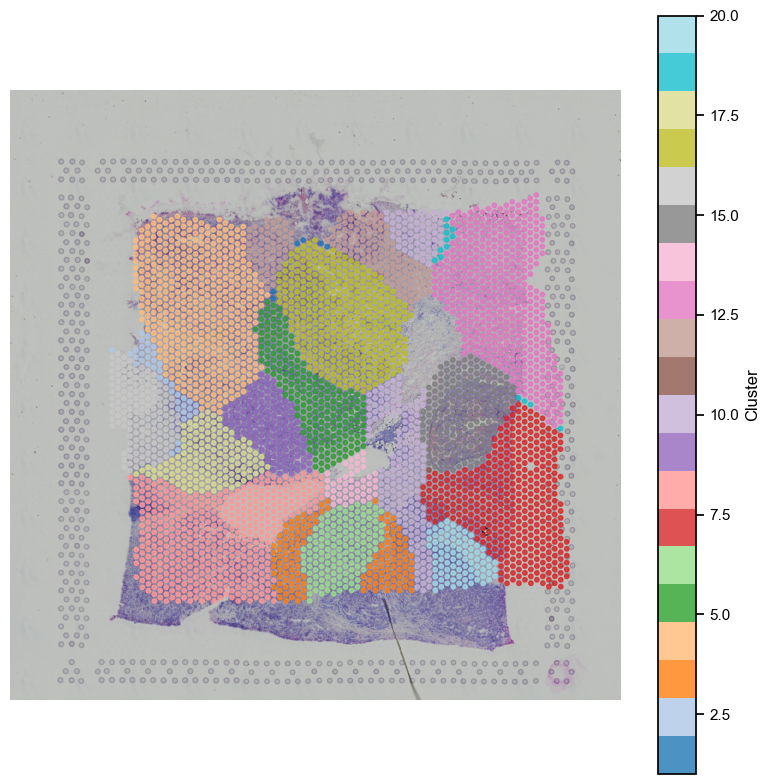


--- Visualizing MISO Clustering Result with scanpy ---
AnnData object with n_obs × n_vars = 3798 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'mclust', 'domain'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial', 'feat_img', 'feat_spot', 'adj_spot_s', 'adj_spot_x', 'adj_spot_i', 'emb', 'emb_pca'


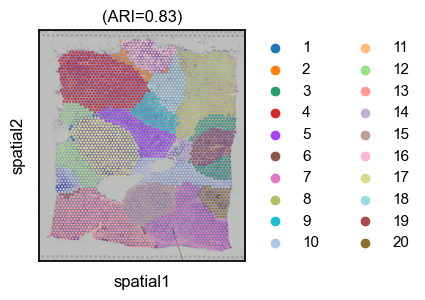

In [ ]:
import sys
import os
os.chdir(REPO_ROOT)
from dcpbst.hist_features import get_features
from dcpbst.utils import *
from dcpbst.model_827_copy import Dcpbst
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as scs
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import scanpy as sc
import matplotlib.pyplot as plt
import random
from dcpbst.evals import *
from dcpbst.preprocess import *
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import json
from tqdm import tqdm
import networkx as nx
import scipy.sparse as sp
from torch.backends import cudnn
import torchvision.models as models
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.csc import csc_matrix
from scipy.sparse.csr import csr_matrix
import torchvision.transforms as transforms
import cv2
from sklearn.preprocessing import LabelEncoder
import importlib_metadata 
from PIL import Image
import pandas as pd
import numpy as np
import json
import os
from sklearn.metrics.cluster import contingency_matrix
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score, \
    homogeneity_completeness_v_measure, calinski_harabasz_score, davies_bouldin_score
seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")

# --------------------------
# --------------------------
SAVE_DIR = RESULTS_DIR  # Directory for saving results
os.makedirs(SAVE_DIR, exist_ok=True)  # Create if not exists
ADATA_SAVE_PATH = os.path.join(SAVE_DIR, 'dcpbst_adata_with_clusters.h5ad')  # adata save path
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'dcpbst_model.pth')  # Model parameter save path
EVAL_DF_SAVE_PATH = os.path.join(SAVE_DIR, 'dcpbst_clustering_metrics.csv')  # Evaluation metric save path

def load_visium_with_labels(path, label_col='fine_annot_type'):
    adata = sc.read_visium(path, load_images=True)
    adata.var_names_make_unique()

    # Read metadata.tsv as labels
    metadata_path = os.path.join(path, "metadata.tsv")
    if os.path.exists(metadata_path):
        meta_df = pd.read_csv(metadata_path, sep="\t")
        assert label_col in meta_df.columns, f"{label_col} not in metadata.tsv"
        adata.obs["Ground Truth"] = meta_df[label_col].values
    else:
        raise FileNotFoundError("metadata.tsv not found")

    # Remove unlabeled entries
    adata = adata[~pd.isnull(adata.obs["Ground Truth"])]
    return adata

# Image parameters
def extract_scalefactors(path):
    scale_path = os.path.join(path, "spatial", "scalefactors_json.json")
    with open(scale_path, "r") as f:
        scale_info = json.load(f)

    spot_diameter = scale_info["spot_diameter_fullres"]
    hires_scalef = scale_info["tissue_hires_scalef"]
    return spot_diameter, hires_scalef 

# Preprocessing
def preprocess_rna(adata):
    sc.pp.filter_genes(adata,min_cells=10)
    sc.pp.log1p(adata)

    return adata

def preprocess_rna_dlpfc(adata):
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata[:, adata.var['highly_variable']]

# Image feature extraction - ResNet algorithm + preprocessed segmentation
def extract_image_features_resnet(
        adata,
        data_path,
        backbone='ResNet50',
        device='cpu',
):
    if backbone == 'ResNet50':
        img_model = models.resnet50(pretrained=True)
        img_model.to(device)

    # Store npy files of segmented images
    full_image = cv2.imread(os.path.join(data_path, "spatial", "full_image.tif"))
    full_image = cv2.cvtColor(full_image, cv2.COLOR_BGR2RGB)
    save_dir = 'cut_img_BRCA'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    save_path = str(save_dir + '/' + 'cut_img_BRCA' + '.npy')
    print(save_path)
    img_size=224
    # save to 'cut_img_DLPFC/cut_img_151509.npy'
    if not os.path.exists(save_path):
        patches = []
        for x, y in adata.obsm['spatial']:
            patch = full_image[y - img_size:y + img_size, x - img_size:x + img_size]
            patches.append(patch)
        patches = np.array(patches)
        np.save(save_path, patches)

    print("cutting image  finished!")

    full_image_path=os.path.join(data_path, "spatial", "full_image.tif")
    im = Image.open(full_image_path)

    path = str(save_dir + '/' + 'cut_img_BRCA' + '.npy')
    print(path)
    save_path = str(save_dir + '/' + 'Img_feat_brca' + '.npy')

    assert os.path.exists(path)
    spot_img = np.load(path)
    spot_img = spot_img.astype(np.float32) / 255.0
    tensor = torch.from_numpy(spot_img)

    img_feat = []

    if not os.path.exists(save_path):
        for i, element in tqdm(enumerate(tensor)):
            element = element.resize_(1, 3, 224, 224)
            element = element.to(device)
            ret = img_model(element)
            ret = ret.data.cpu().numpy().ravel()
            img_feat.append(ret)
        np.save(save_path, img_feat)
        img_feat = np.array(img_feat)
    else:
        img_feat = np.load(save_path)
    print("the image feature has been extracted!")
    adata.obsm['feat_img'] = img_feat
    return adata

# Image feature extraction - global-local multi-scale extraction algorithm
def extract_image_features(data_path, pixel_size=0.5, device='cuda', adata=None):


    full_image_path = os.path.join(data_path, "spatial", "full_image.tif")
    im = Image.open(full_image_path)

    locs_path = os.path.join(data_path, "spatial", "tissue_positions_list.csv")
    locs = pd.read_csv(locs_path, index_col=0)
    locs.columns = [str(i) for i in range(1, 6)]

    # Add this code: ensure locs align with adata
    if adata is not None:
        locs = locs.loc[adata.obs_names]

    # Load scalefactor
    scale_path = os.path.join(data_path, "spatial", "scalefactors_json.json")
    with open(scale_path, "r") as f:
        scalefactors = json.load(f)
    spot_diameter = scalefactors["spot_diameter_fullres"]
    pixel_size_raw = 55 / spot_diameter
    rad = 55 / (2 * pixel_size_raw)

    image_emb = get_features(im, locs, rad, pixel_size_raw, pixel_size, pretrained=True, device=device)

    return image_emb, locs

def purity_score(y_true, y_pred):
    cm = contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)

def search_res(adata, n_clusters, method='leiden', use_rep='emb', start=0.1, end=3.0, increment=0.01):
    print('Searching resolution...')
    label = 0
    sc.pp.neighbors(adata, n_neighbors=50, use_rep=use_rep)
    for res in sorted(list(np.arange(start, end, increment)), reverse=True):
        if method == 'leiden':
            sc.tl.leiden(adata, random_state=0, resolution=res)
            count_unique = len(pd.DataFrame(adata.obs['leiden']).leiden.unique())
            print('resolution={}, cluster number={}'.format(res, count_unique))
        elif method == 'louvain':
            sc.tl.louvain(adata, random_state=0, resolution=res)
            count_unique = len(pd.DataFrame(adata.obs['louvain']).louvain.unique())
            print('resolution={}, cluster number={}'.format(res, count_unique))
        if count_unique == n_clusters:
            label = 1
            break

    assert label == 1, "Resolution is not found. Please try bigger range or smaller step!."

    return res

# 2. Define clustering-related metric calculation
def refine_label(adata, radius=50, key='label'):
    n_neigh = radius
    new_type = []
    old_type = adata.obs[key].values

    # calculate distance
    position = adata.obsm['spatial']
    distance = ot.dist(position, position, metric='euclidean')

    n_cell = distance.shape[0]

    for i in range(n_cell):
        vec = distance[i, :]
        index = vec.argsort()
        neigh_type = []
        for j in range(1, n_neigh + 1):
            neigh_type.append(old_type[index[j]])
        max_type = max(neigh_type, key=neigh_type.count)
        new_type.append(max_type)

    new_type = [str(i) for i in list(new_type)]

    return new_type

def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=2024):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    print(res)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    return adata

def calculate_clustering_matrix(df, y_pred, ground_truth):
    ari = adjusted_rand_score(y_pred, ground_truth)
    nmi = normalized_mutual_info_score(y_pred, ground_truth)
    purity = purity_score(y_pred, ground_truth)
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(y_pred, ground_truth)
    print("ARI={}, NMI={},Purity={},V_Measure={}".format(ari, nmi,purity,v_measure))

    new_row = pd.DataFrame([{
        'ARI': ari,
        'NMI': nmi,
        'Purity': purity,
        'Homogeneity': homogeneity,
        'Completeness': completeness,
        'V_Measure': v_measure
        # 'Sample' and 'methods' columns can be added later or adjusted as needed
    }])

    # 2. Use pd.concat to merge new rows into existing DataFrame
    df = pd.concat([df, new_row], ignore_index=True)
    
    return df

def clustering(adata, n_clusters=7, radius=50, key='emb', method='mclust', start=0.1, end=3.0, increment=0.01,
               refinement=False):# Changed a parameter setting
    # PCA dimensionality reduction done before clustering
    pca = PCA(n_components=20, random_state=2024)
    embedding = pca.fit_transform(adata.obsm[key].copy())
    adata.obsm['emb_pca'] = embedding


    if method == 'mclust':
        adata = mclust_R(adata, used_obsm='emb_pca', num_cluster=n_clusters)
        adata.obs['domain'] = adata.obs['mclust']
    elif method == 'kmeans':
        kmeans = KMeans(n_clusters=n_clusters).fit(embedding)
        kmeans_result = [i + 1 for i in kmeans.labels_]
        adata.obs['domain'] = list(map(lambda x: str(x), kmeans_result))
    elif method == 'leiden':
        res = search_res(adata, n_clusters, use_rep='emb_pca', method=method, start=start, end=end, increment=increment)
        sc.tl.leiden(adata, random_state=0, resolution=res)
        adata.obs['domain'] = adata.obs['leiden']
    elif method == 'louvain':
        res = search_res(adata, n_clusters, use_rep='emb_pca', method=method, start=start, end=end, increment=increment)
        sc.tl.louvain(adata, random_state=0, resolution=res)
        adata.obs['domain'] = adata.obs['louvain']

    if refinement:
        new_type = refine_label(adata, radius, key='domain')
        adata.obs['domain'] = new_type

def plot_on_histology(clusters, locs, im, scale, s=10):
 """Draw spatial clustering results on tissue section"""
    plt.figure(figsize=(8, 8))
    plt.imshow(im)
    # Convert spatial coordinates to image coordinates
    x = locs['4'].values * scale
    y = locs['5'].values * scale
    # Draw for each spot
    scatter = plt.scatter(x, y, c=clusters, s=s, cmap='tab20', alpha=0.8)
    plt.colorbar(scatter, label='Cluster')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def run_dcpbst_pipeline(data_path, device='cuda', label_col='fine_annot_type', section_id='151509', save_csv=True, save_results=True):
    df = pd.DataFrame(columns=['Sample', 'ARI', 'NMI', 'Purity', 'Homogeneity', 'Completeness', 'V_Measure', 'methods'])
    adata = load_visium_with_labels(data_path, label_col)
    print(f"Loaded data: {adata.shape}")
    adata = preprocess_rna_dlpfc(adata)
    if scipy.sparse.issparse(adata.X):
       scrna=adata.X.A
    else:
       scrna=adata.X
    print("scrna shape:", scrna.shape)

    if 'feat_img' not in adata.obsm.keys():
 extract_image_features_resnet(adata, data_path=data_path,device=device)# #Geteach spotPlotimage features
    image_emb=adata.obsm['feat_img']
    print("image_emb shape:", image_emb.shape)
    n_clusters=len(set(adata.obs["Ground Truth"]))
    print(n_clusters)
    model = Dcpbst([scrna,image_emb],sparse=False,device=device,n_clusters=n_clusters,adata=adata,neighbors=7)
    
    embedding=model.fit()
    adata.obsm['emb']=embedding

    # 3. Pass it into the clustering method
    radius = 50
    tool = 'mclust'
    if tool == 'mclust':
        clustering(adata, n_clusters=n_clusters, radius=radius, method=tool,
                   refinement=True)  # For DLPFC dataset, we use optional refinement step.
    elif tool == 'kmeans':
        clustering(adata, n_clusters=n_clusters, method=tool)
    elif tool in ['leiden', 'louvain']:
        clustering(adata, n_clusters=n_clusters, radius=radius, method=tool, start=0.1, end=2.0, increment=0.01,
                   refinement=True)
    df = calculate_clustering_matrix(df, adata.obs['domain'], adata.obs['Ground Truth'])
    print(df)
    df.to_csv('BRCA-0830.csv')

    # --------------------------
    # New: save results
    # --------------------------
    if save_results:
        print(f"\nSaving results to {SAVE_DIR}...")
        adata.write_h5ad(ADATA_SAVE_PATH)
        print(f"✅ adata saved to {ADATA_SAVE_PATH}")
        
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"✅ Model state_dict saved to {MODEL_SAVE_PATH}")
        
        # Save evaluation metrics
        df.to_csv(EVAL_DF_SAVE_PATH, index=False)
        print(f"✅ Evaluation metrics saved to {EVAL_DF_SAVE_PATH}")

    return adata, model, df

# --------------------------
# New: function to load saved results
# --------------------------
def load_saved_results():
    """Load saved adata, model parameters, and evaluation metrics"""
    print(f"Loading saved results from {SAVE_DIR}...")
    
    adata = sc.read_h5ad(ADATA_SAVE_PATH)
    print(f"✅ Loaded adata: {adata.shape}")
    print(f"✅ Clustering results available in adata.obs['domain']")
    print(f"✅ Unique clusters: {sorted(adata.obs['domain'].unique())}")
    
    # Load evaluation metrics
    eval_df = pd.read_csv(EVAL_DF_SAVE_PATH)
    print(f"✅ Loaded evaluation metrics")
    
    # Adjust based on your Dcpbst class initialization logic, example below
    
    return adata, eval_df  # Return model if needed

# --------------------------
# Main logic: Choose training or loading
# --------------------------
LOAD_FROM_SAVED = False  # True=load saved results, False=retrain and save

if LOAD_FROM_SAVED:
    adata, eval_df = load_saved_results()
    model = None  # Set to None if model not needed
else:
    # Retrain and save results
    adata, model, eval_df = run_dcpbst_pipeline(
        data_path=os.path.join(DATA_DIR, 'Human_breast'), 
        device='cuda',
        save_results=True  # Save results after training
    )

# --------------------------
# --------------------------
final_clusters = adata.obs['domain']

# 2. Get list and count of unique categories
unique_clusters = final_clusters.unique()
num_final_clusters = len(unique_clusters)

print(f"\nList of unique categories in final clustering results: {sorted(unique_clusters)}")
print(f"Total number of categories in final clustering results: {num_final_clusters}")

print("\nCell count statistics for each cluster:")
print(final_clusters.value_counts())

data_path=os.path.join(DATA_DIR, 'Human_breast')
# Write visualization-related code:
locs_path = os.path.join(data_path, "spatial", "tissue_positions_list.csv")
locs = pd.read_csv(locs_path, header=None, index_col=0)
locs.columns = ['in_tissue', 'array_row', 'array_col', '4', '5']

locs = locs.loc[adata.obs_names]

# 3. Get clustering results
clusters = adata.obs['domain'].astype(int).values

# 4. Read tissue image
im = plt.imread(os.path.join(data_path, "spatial", "tissue_hires_image.png"))
# 5. Get scaling factor
with open(os.path.join(data_path, "spatial", "scalefactors_json.json"), "r") as f:
    scalefactors = json.load(f)
scale = scalefactors["tissue_hires_scalef"] 
# 6. Visualization
plot_on_histology(clusters, locs, im, scale, s=10)

print("\n--- Visualizing DCPBST Clustering Result with scanpy ---")

# --- Data preparation ---
# Extract ARI score for title
try:
    ari_score = eval_df['ARI'].iloc[0]
except:
    ari_score = 0.0
print(adata)

# Define column name for clustering results
plt.rcParams["figure.figsize"] = (3,3)

sc.pl.spatial(
    adata,
    # <<< Modified: color parameter only provides a column name string >>>
    color="domain",
    # <<< Modified: title parameter only provides a column name string >>>
    title=f'(ARI={ari_score:.2f})',
)


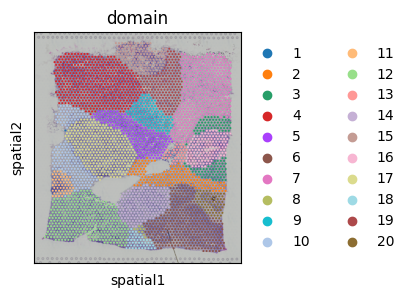

In [2]:
sc.pl.spatial(
    adata,
    # <<< Modified: color parameter only provides a column name string >>>
    color="domain",
    # <<< Modified: title parameter only provides a column name string >>>
)

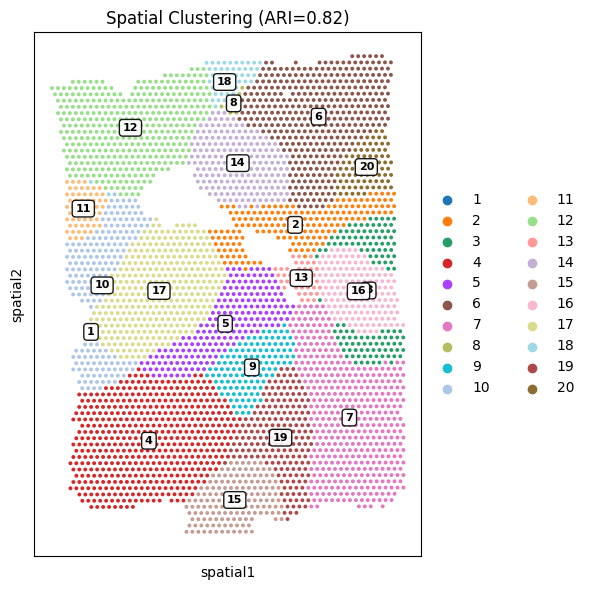

<Figure size 600x600 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

# Data preparation
try:
    ari_score = eval_df['ARI'].iloc[0]
except:
    ari_score = 0.0
cluster_key = "domain"
spatial_key = "spatial"  # Spatial coordinates key

plt.rcParams["figure.figsize"] = (6, 6)
sc.pl.embedding(
    adata,
    basis=spatial_key,  # Specify spatial coordinates as "embedding"
    color=cluster_key,
    title=f'Spatial Clustering (ARI={ari_score:.2f})',
    show=False
)

# Get current axis object, add labels
ax = plt.gca()
clusters = adata.obs[cluster_key].unique()
for cluster in clusters:
    # Filter cluster cells, calculate spatial center
    cluster_cells = adata[adata.obs[cluster_key] == cluster]
    center = np.mean(cluster_cells.obsm[spatial_key], axis=0)
    # Add labels
    ax.text(
        center[0], center[1],
        str(cluster),
        fontsize=8,
        fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9)
    )

plt.tight_layout()
plt.show()
plt.savefig('spatial_clustering_custom_embedding.pdf', bbox_inches='tight')

print(adata)

In [4]:
print(adata)

AnnData object with n_obs × n_vars = 3798 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'mclust', 'domain'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p', 'domain_colors'
    obsm: 'spatial', 'feat_img', 'feat_spot', 'adj_spot_s', 'adj_spot_x', 'adj_spot_i', 'emb', 'emb_pca'


In [5]:
import scanpy as sc
import pandas as pd
import scipy

# --------------------------
# --------------------------
adata_subset = adata[adata.obs['domain'].isin(['8', '12'])].copy()
print(f"Cell count after filtering:{adata_subset.n_obs}, gene count:{adata_subset.n_vars}")

expr_matrix = adata_subset.X  # Original dimensions: (cells, genes)
# If sparse matrix, transpose then convert to dense; if dense, transpose directly
if scipy.sparse.issparse(expr_matrix):
    expr_matrix = expr_matrix.T.toarray()  # Dimensions after transpose: (genes, cells)
else:
    expr_matrix = expr_matrix.T  # Dimensions after transpose: (genes, cells)

print(f"Transposed expression matrix dimensions:{expr_matrix.shape} (genes × cells)")
print(f"Gene name count:{len(adata_subset.var_names)},Cell name count:{len(adata_subset.obs_names)}")

# --------------------------
# --------------------------
heatmap_data = pd.DataFrame(
    expr_matrix,
    index=adata_subset.var_names,  # Row names: gene names (count=expr_matrix row count)
    columns=adata_subset.obs_names  # Column names: cell names (count=expr_matrix column count)
)

heatmap_data.to_csv('data.heatmap.txt', sep='\t', float_format='%.6f')
print("✅ Heatmap data file saved:data.heatmap.txt")

# --------------------------
# --------------------------
sample_class = adata_subset.obs[['domain']].copy()
sample_class.columns = ['Group'] # Column name changed to "Group" (common for web tools)
sample_class.index.name = 'Sample' # Row name changed to "Sample" (optional, enhances readability)

# Save as tab-separated txt file
sample_class.to_csv('sample.class.txt', sep='\t')
print("✅ Sample grouping file saved:sample.class.txt")

# --------------------------
# --------------------------
print("\nFile details:")
print(f"- Heatmap data:{heatmap_data.shape[0]}  genes × {heatmap_data.shape[1]} Cell")
print(f"- Sample grouping:{len(sample_class)} Cell,GroupType:{sample_class['Group'].unique()}")
print(f"- clusters8Cell count:{len(sample_class[sample_class['Group']=='8'])}")
print(f"- clusters12Cell count:{len(sample_class[sample_class['Group']=='12'])}")

筛选后细胞数：398，基因数：3000
转置后表达矩阵维度：(3000, 398)（基因数 × 细胞数）
基因名数量：3000，细胞名数量：398
✅ 热图数据文件已保存：data.heatmap.txt
✅ 样本分组文件已保存：sample.class.txt

文件详情：
- 热图数据：3000 个基因 × 398 个细胞
- 样本分组：398 个细胞，分组类型：['12', '8']
Categories (2, object): ['8', '12']
- 聚类8细胞数：10
- 聚类12细胞数：388


开始分析：区域12 vs 区域14

正在进行差异基因分析（全量数据集，12 vs 14）...
差异基因分析成功（use_raw=False）

差异基因统计（簇12 vs 簇14）：43 个显著差异基因
Top10差异基因：
       names  logfoldchanges     pvals
0     ADGRB1        2.981710  0.004068
1      LIN7A        2.806698  0.042726
2      ADCY5        2.359440  0.046314
3    CACNA1H        2.330391  0.017468
4   MAPK8IP2        2.276355  0.002369
5        LTF        2.168952  0.042064
6      FBLN2        2.114540  0.007161
7  LINC02224        2.102499  0.031651
8    KLHDC7B        2.082457  0.000093
9      PTGDS        2.027903  0.000022
选取Top基因：12上调5个，14上调5个，共10个


/root/miniconda3/envs/miso/lib/python3.7/site-packages/ipykernel_launcher.py:53: FutureWarning: elementwise == comparison failed and returning scalar instead; this will raise an error or perform elementwise comparison in the future.
/root/miniconda3/envs/miso/lib/python3.7/site-packages/ipykernel_launcher.py:231: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations


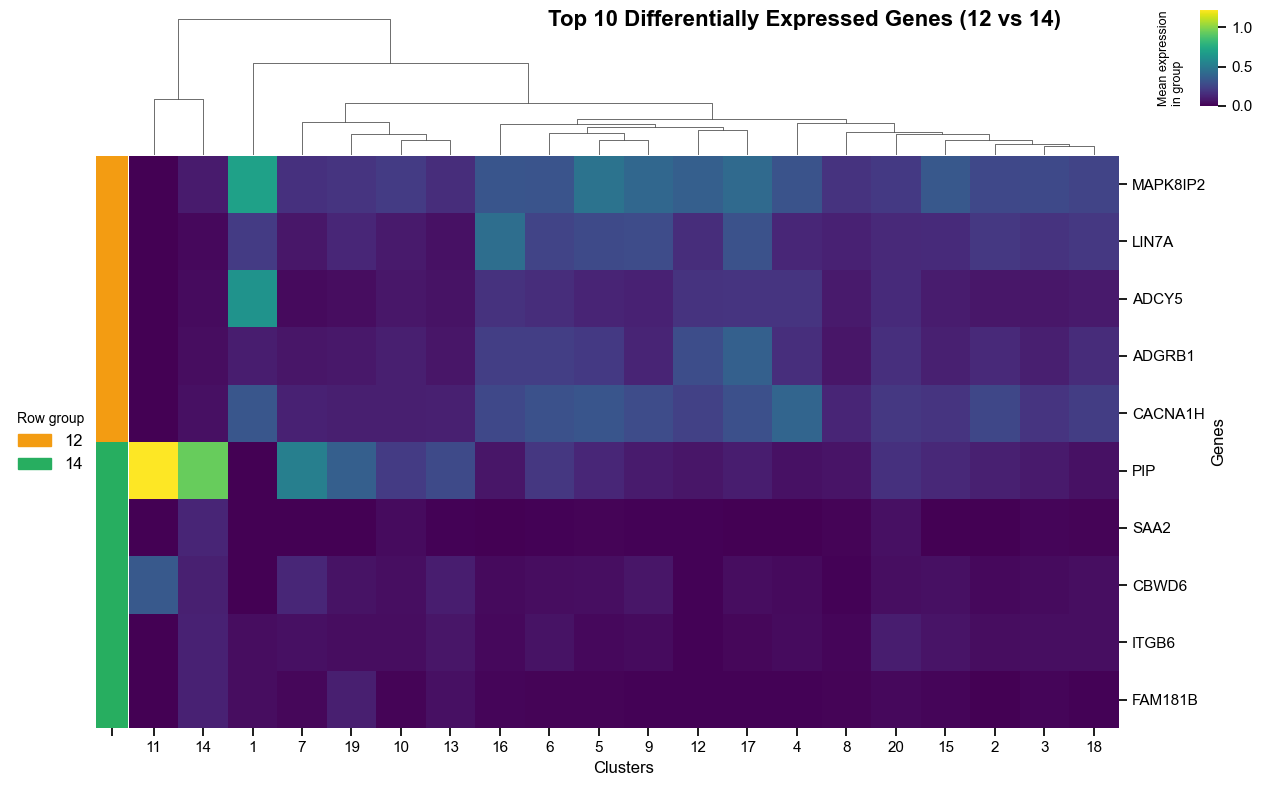

In [10]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy.stats import mannwhitneyu
import seaborn as sns

adata = sc.read(os.path.join(REPO_ROOT, 'saved_results/dcpbst_adata_with_clusters.h5ad'))

# --------------------------
# Basic settings
# --------------------------
cluster_key = 'domain'  # Clustering result column name
logfc_thresh = 2        # log2FC threshold
pval_thresh = 0.05      # P-value threshold
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.figsize'] = (12, 8)

# --------------------------
# Core fix: resolve log1p 'base' KeyError
# --------------------------
def fix_log1p_metadata(adata):
    if 'log1p' not in adata.uns:
        adata.uns['log1p'] = {}
    if 'base' not in adata.uns['log1p']:
        adata.uns['log1p']['base'] = None
    return adata

# --------------------------
# --------------------------
def get_rank_genes_groups_df_compat(adata, group):
    """
    Compatible with allScanpyVersion of differential gene extraction function
    First check dict type,Then checkrecarrayType,Avoid attribute error
    """
    rank_genes = adata.uns['rank_genes_groups']

    if isinstance(rank_genes, dict):
        genes = rank_genes['names'][group]
        logfc = rank_genes['logfoldchanges'][group]
        pvals = rank_genes['pvals'][group]
    else:  # recarrayType
        genes = rank_genes['names'][group]
        logfc = rank_genes['logfoldchanges'][group]
        pvals = rank_genes['pvals'][group]

    pvals_adj = np.full_like(genes, np.nan, dtype=float)  # Default fill with NaN
    if isinstance(rank_genes, dict):
        if 'pvals_adj' in rank_genes and group in rank_genes['pvals_adj']:
            pvals_adj = rank_genes['pvals_adj'][group]
    else:  # recarrayType
        if 'pvals_adj' in rank_genes.dtype.names:
            pvals_adj = rank_genes['pvals_adj'][group]

    # 3. Build DataFrame and clean invalid data
    de_df = pd.DataFrame({
        'names': genes,
        'logfoldchanges': logfc,
        'pvals': pvals,
        'pvals_adj': pvals_adj
    })
    de_df = de_df.dropna(subset=['names', 'logfoldchanges', 'pvals'])
    de_df['names'] = de_df['names'].astype(str)
    return de_df

# --------------------------
# --------------------------
print("=" * 60)
print("Start analysis:region 12 vs region 14")
print("=" * 60)

adata = fix_log1p_metadata(adata)

print("\nPerforming differential gene analysis (full dataset, 12 vs 14)...")
try:
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        groups=['12'],
        reference='14',
        method='wilcoxon',
        log2fc_min=logfc_thresh,
        use_raw=False
    )
    print("Differential gene analysis successful (use_raw=False)")
except Exception as e:
    print(f"use_raw=FalseFailed: {str(e)[:100]},Attemptuse_raw=True...")
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        groups=['12'],
        reference='14',
        method='wilcoxon',
        log2fc_min=logfc_thresh,
        use_raw=True
    )
    print("Differential gene analysis successful (use_raw=True)")

de_df = get_rank_genes_groups_df_compat(adata, group='12')

# --------------------------
# Step 2: Screen significant differential genes and take top 10
# --------------------------
de_signif = de_df[
    (abs(de_df['logfoldchanges']) >= logfc_thresh) &
    (de_df['pvals'] < pval_thresh)
].sort_values('logfoldchanges', ascending=False).reset_index(drop=True)

print(f"\nDifferential gene statistics (cluster 12 vs cluster 14):{len(de_signif)}  significant differential genes")
print("Top 10 differential genes:")
print(de_signif[['names', 'logfoldchanges', 'pvals']].head(10))

n_genes = 10
half = n_genes // 2
up12 = de_signif[de_signif['logfoldchanges'] > 2].sort_values('logfoldchanges', ascending=False)
down14 = de_signif[de_signif['logfoldchanges'] < -2].sort_values('logfoldchanges', ascending=True)
sel_up = up12.head(half)['names'].tolist()
sel_down = down14.head(half)['names'].tolist()
remain = n_genes - (len(sel_up) + len(sel_down))
if remain > 0:
    extra = up12.iloc[half:].head(remain)['names'].tolist() if len(sel_up) < half else down14.iloc[half:].head(remain)['names'].tolist()
    sel_up = sel_up if len(sel_up) >= half else sel_up + extra
    sel_down = sel_down if len(sel_down) >= half else sel_down + extra

top_genes = sel_up + sel_down
print(f"Selected top genes: 12 upregulated {len(sel_up)}, 14 upregulated {len(sel_down)}, total {len(top_genes)}")

# --------------------------
# --------------------------
# Calculate average expression matrix of Top10 genes within each cluster
expr_df = sc.get.obs_df(adata, keys=top_genes, use_raw=False)
expr_df[cluster_key] = adata.obs[cluster_key].values
mean_mat = expr_df.groupby(cluster_key).mean().T

pair_means = mean_mat[[c for c in mean_mat.columns if c in ['12', '14']]].copy()
row_group = pd.Series(index=pair_means.index, dtype=object)
row_group.loc[sel_up] = '12'
row_group.loc[sel_down] = '14'
row_group = row_group.fillna((pair_means['12'] >= pair_means['14']).map(lambda x: '12' if x else '14'))

# Determine row order
from scipy.cluster.hierarchy import linkage, leaves_list
order_indices = []
for grp in ['12', '14']:
    idx = np.where(row_group.values == grp)[0]
    if len(idx) == 0:
        continue
    X2 = pair_means.values[idx]
    if len(idx) > 1:
        leaf = leaves_list(linkage(X2, method='average', metric='euclidean'))
        idx = idx[leaf]
    order_indices.extend(idx)

ordered_genes = list(pair_means.index[order_indices])
mean_mat_ordered = mean_mat.loc[ordered_genes]

row_colors = row_group.loc[ordered_genes].map({'12': '#f39c12', '14': '#27ae60'})

# Draw heatmap: remove legend-related code, adjust layout
sns.set_context('notebook')
g = sns.clustermap(
    mean_mat_ordered,
    cmap='viridis',
    metric='euclidean',
    method='average',
    row_cluster=False,
    col_cluster=True,
    figsize=(12, 8),
    xticklabels=True,
    yticklabels=True,
    row_colors=row_colors,
    cbar_pos=(0.52, 0.86, 0.02, 0.12),  # Fine-tune colorbar position,Avoid left-side blank space
    dendrogram_ratio=(0.05, 0.2)  # Reduce row dendrogram ratio(More compact on left side)
)

# Add row color legend on left, annotate '12' and '14'
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color='#f39c12', label='12'),  # Modification18:Legend label changed to12
 mpatches.Patch(color='#27ae60', label='14') # Modification 19: legend label changed to 14 (color corresponds)
]
try:
    g.ax_row_dendrogram.legend(
        handles=handles,
        title='Row group',
        loc='center left',
        bbox_to_anchor=(-0.75, 0.5),
        frameon=False,
        fontsize=12,
        title_fontsize=10
    )
except Exception:
    pass
fig = g.fig
cax = g.cax
try:
    new_x, new_y, new_w, new_h = 0.98, 0.86, 0.015, 0.12
    cax.set_position([new_x, new_y, new_w, new_h])
    
    # Add vertical text: Mean expression in group
    # rotation=90 for vertical, ha='left' for horizontal left align, va='center' for vertical center
    fig.text(
        x=new_x - 0.035,  # Text on left side of colorbar (horizontal position)
        y=new_y + new_h/2,  # Text vertically center-aligned with colorbar
        s='Mean expression\nin group',  # Line break separator text
        rotation=90,  # Vertical layout (90 degree rotation)
        ha='left',
        va='center',
        fontsize=9,
        fontweight='normal',
        color='black'
    )
except Exception as e:
    print(f"Failed to add colorbar text:{str(e)}")

# Clean up extra axis titles, optimize layout
g.ax_heatmap.set_xlabel('Clusters', fontsize=12)
g.ax_heatmap.set_ylabel('Genes', fontsize=12)
plt.suptitle("Top 10 Differentially Expressed Genes (12 vs 14)", fontsize=16, fontweight='bold', x=0.65)
plt.tight_layout()
plt.show()

开始分析：区域12 vs 区域14

正在进行差异基因分析（全量数据集，12 vs 14）...
差异基因分析成功（use_raw=False）

差异基因统计（簇12 vs 簇14）：43 个显著差异基因
Top10差异基因：
       names  logfoldchanges     pvals
0     ADGRB1        2.981710  0.004068
1      LIN7A        2.806698  0.042726
2      ADCY5        2.359440  0.046314
3    CACNA1H        2.330391  0.017468
4   MAPK8IP2        2.276355  0.002369
5        LTF        2.168952  0.042064
6      FBLN2        2.114540  0.007161
7  LINC02224        2.102499  0.031651
8    KLHDC7B        2.082457  0.000093
9      PTGDS        2.027903  0.000022
选取Top基因：12上调5个，14上调5个，共10个


/root/miniconda3/envs/miso/lib/python3.7/site-packages/ipykernel_launcher.py:53: FutureWarning: elementwise == comparison failed and returning scalar instead; this will raise an error or perform elementwise comparison in the future.
/root/miniconda3/envs/miso/lib/python3.7/site-packages/ipykernel_launcher.py:218: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from current font.
/root/miniconda3/envs/miso/lib/python3.7/site-packages/ipykernel_launcher.py:218: UserWarning: Glyph 35843 (\N{CJK UNIFIED IDEOGRAPH-8C03}) missing from current font.
/root/miniconda3/envs/miso/lib/python3.7/site-packages/ipykernel_launcher.py:218: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
/root/miniconda3/envs/miso/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/minicon

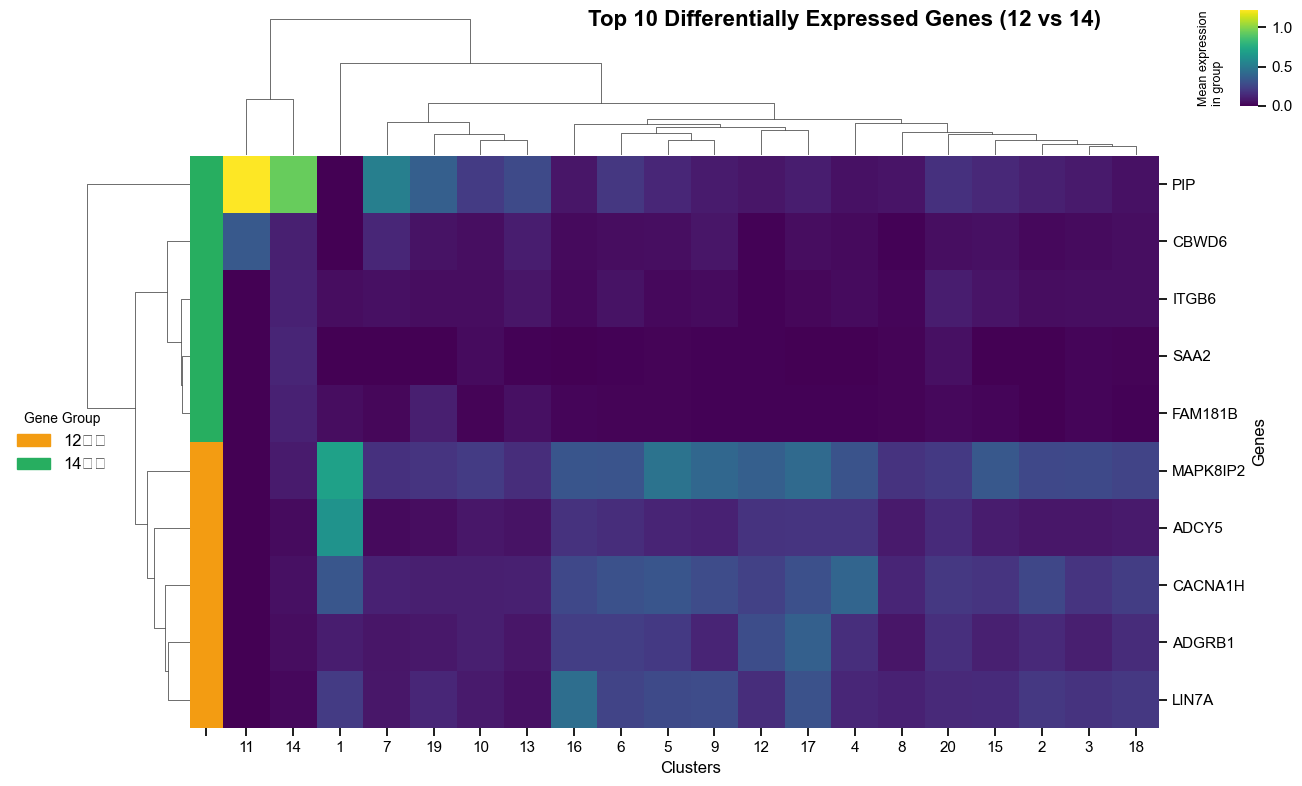

In [11]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy.stats import mannwhitneyu
import seaborn as sns

adata = sc.read(os.path.join(REPO_ROOT, 'saved_results/dcpbst_adata_with_clusters.h5ad'))

# --------------------------
# Basic settings
# --------------------------
cluster_key = 'domain'  # Clustering result column name
logfc_thresh = 2        # log2FC threshold
pval_thresh = 0.05      # P-value threshold
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.figsize'] = (12, 8)

# --------------------------
# Core fix: resolve log1p 'base' KeyError
# --------------------------
def fix_log1p_metadata(adata):
    if 'log1p' not in adata.uns:
        adata.uns['log1p'] = {}
    if 'base' not in adata.uns['log1p']:
        adata.uns['log1p']['base'] = None
    return adata

# --------------------------
# --------------------------
def get_rank_genes_groups_df_compat(adata, group):
    """
    Compatible with allScanpyVersion of differential gene extraction function
    First check dict type,Then checkrecarrayType,Avoid attribute error
    """
    rank_genes = adata.uns['rank_genes_groups']

    if isinstance(rank_genes, dict):
        genes = rank_genes['names'][group]
        logfc = rank_genes['logfoldchanges'][group]
        pvals = rank_genes['pvals'][group]
    else:  # recarrayType
        genes = rank_genes['names'][group]
        logfc = rank_genes['logfoldchanges'][group]
        pvals = rank_genes['pvals'][group]

    pvals_adj = np.full_like(genes, np.nan, dtype=float)  # Default fill with NaN
    if isinstance(rank_genes, dict):
        if 'pvals_adj' in rank_genes and group in rank_genes['pvals_adj']:
            pvals_adj = rank_genes['pvals_adj'][group]
    else:  # recarrayType
        if 'pvals_adj' in rank_genes.dtype.names:
            pvals_adj = rank_genes['pvals_adj'][group]

    # 3. Build DataFrame and clean invalid data
    de_df = pd.DataFrame({
        'names': genes,
        'logfoldchanges': logfc,
        'pvals': pvals,
        'pvals_adj': pvals_adj
    })
    de_df = de_df.dropna(subset=['names', 'logfoldchanges', 'pvals'])
    de_df['names'] = de_df['names'].astype(str)
    return de_df

# --------------------------
# --------------------------
print("=" * 60)
print("Start analysis:region 12 vs region 14")
print("=" * 60)

adata = fix_log1p_metadata(adata)

print("\nPerforming differential gene analysis (full dataset, 12 vs 14)...")
try:
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        groups=['12'],
        reference='14',
        method='wilcoxon',
        log2fc_min=logfc_thresh,
        use_raw=False
    )
    print("Differential gene analysis successful (use_raw=False)")
except Exception as e:
    print(f"use_raw=FalseFailed: {str(e)[:100]},Attemptuse_raw=True...")
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        groups=['12'],
        reference='14',
        method='wilcoxon',
        log2fc_min=logfc_thresh,
        use_raw=True
    )
    print("Differential gene analysis successful (use_raw=True)")

de_df = get_rank_genes_groups_df_compat(adata, group='12')

# --------------------------
# Step 2: Screen significant differential genes and take top 10
# --------------------------
de_signif = de_df[
    (abs(de_df['logfoldchanges']) >= logfc_thresh) &
    (de_df['pvals'] < pval_thresh)
].sort_values('logfoldchanges', ascending=False).reset_index(drop=True)

print(f"\nDifferential gene statistics (cluster 12 vs cluster 14):{len(de_signif)}  significant differential genes")
print("Top 10 differential genes:")
print(de_signif[['names', 'logfoldchanges', 'pvals']].head(10))

n_genes = 10
half = n_genes // 2
up12 = de_signif[de_signif['logfoldchanges'] > 2].sort_values('logfoldchanges', ascending=False)
down14 = de_signif[de_signif['logfoldchanges'] < -2].sort_values('logfoldchanges', ascending=True)
sel_up = up12.head(half)['names'].tolist()
sel_down = down14.head(half)['names'].tolist()
remain = n_genes - (len(sel_up) + len(sel_down))
if remain > 0:
    extra = up12.iloc[half:].head(remain)['names'].tolist() if len(sel_up) < half else down14.iloc[half:].head(remain)['names'].tolist()
    sel_up = sel_up if len(sel_up) >= half else sel_up + extra
    sel_down = sel_down if len(sel_down) >= half else sel_down + extra

top_genes = sel_up + sel_down
print(f"Selected top genes: 12 upregulated {len(sel_up)}, 14 upregulated {len(sel_down)}, total {len(top_genes)}")

# --------------------------
# --------------------------
expr_df = sc.get.obs_df(adata, keys=top_genes, use_raw=False)
expr_df[cluster_key] = adata.obs[cluster_key].values
mean_mat = expr_df.groupby(cluster_key).mean().T

# --------------------------
# Key Modification 1: Remove all forced grouping and row order specification code below
# --------------------------

# --------------------------
# --------------------------
row_colors = pd.Series(index=top_genes, dtype=object)
row_colors.loc[sel_up] = '#f39c12'  # 12 upregulated -> orange
row_colors.loc[sel_down] = '#27ae60'  # 14 upregulated -> green

# --------------------------
# --------------------------
sns.set_context('notebook')
g = sns.clustermap(
    mean_mat,  # Directly use original average expression matrix, do not intervene in row order
    cmap='viridis',
    metric='euclidean',
    method='average',
    row_cluster=True,  # Enable row clusters (default behavior, genes naturally cluster by expression pattern)
    col_cluster=True,
    figsize=(12, 8),
    xticklabels=True,
    yticklabels=True,
    row_colors=row_colors,  # Retain gene assignment color annotation
    cbar_pos=(0.52, 0.86, 0.02, 0.12),
    dendrogram_ratio=(0.1, 0.2)  # Adjust row dendrogram ratio (adapt for clustering display)
)

import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color='#f39c12', label='12Upregulated'),
    mpatches.Patch(color='#27ae60', label='14Upregulated')
]
try:
    g.ax_row_dendrogram.legend(
        handles=handles,
        title='Gene Group',
        loc='center left',
        bbox_to_anchor=(-0.75, 0.5),
        frameon=False,
        fontsize=12,
        title_fontsize=10
    )
except Exception:
    pass

# Adjust colorbar position
fig = g.fig
cax = g.cax
try:
    new_x, new_y, new_w, new_h = 0.98, 0.86, 0.015, 0.12
    cax.set_position([new_x, new_y, new_w, new_h])
    
    # Add vertical text: Mean expression in group
    fig.text(
        x=new_x - 0.035,
        y=new_y + new_h/2,
        s='Mean expression\nin group',
        rotation=90,
        ha='left',
        va='center',
        fontsize=9,
        fontweight='normal',
        color='black'
    )
except Exception as e:
    print(f"Failed to add colorbar text:{str(e)}")

# Optimize layout and title
g.ax_heatmap.set_xlabel('Clusters', fontsize=12)
g.ax_heatmap.set_ylabel('Genes', fontsize=12)
plt.suptitle("Top 10 Differentially Expressed Genes (12 vs 14)", fontsize=16, fontweight='bold', x=0.65)
plt.tight_layout()
plt.show()

开始分析：区域12 vs 14

正在进行差异基因分析（全量数据集，12 vs 14）...
差异基因分析成功（use_raw=False）

差异基因统计（簇12 vs 簇14）：43 个显著差异基因
Top10差异基因：
       names  logfoldchanges     pvals
0     ADGRB1        2.981710  0.004068
1      LIN7A        2.806698  0.042726
2      ADCY5        2.359440  0.046314
3    CACNA1H        2.330391  0.017468
4   MAPK8IP2        2.276355  0.002369
5        LTF        2.168952  0.042064
6      FBLN2        2.114540  0.007161
7  LINC02224        2.102499  0.031651
8    KLHDC7B        2.082457  0.000093
9      PTGDS        2.027903  0.000022

选取Top10差异基因：['ADGRB1', 'LIN7A', 'ADCY5', 'CACNA1H', 'MAPK8IP2', 'LTF', 'FBLN2', 'LINC02224', 'KLHDC7B', 'PTGDS']


/root/miniconda3/envs/miso/lib/python3.7/site-packages/ipykernel_launcher.py:51: FutureWarning: elementwise == comparison failed and returning scalar instead; this will raise an error or perform elementwise comparison in the future.
/root/miniconda3/envs/miso/lib/python3.7/site-packages/ipykernel_launcher.py:183: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations


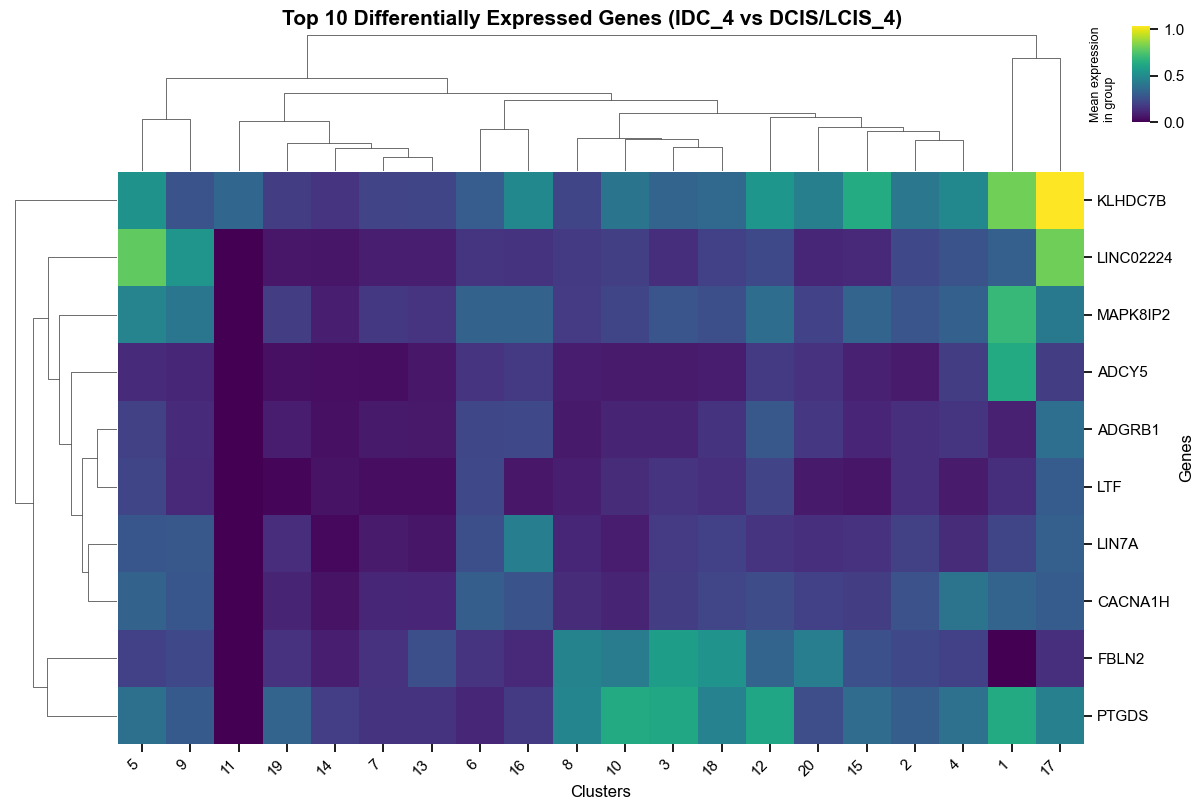

In [14]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy.stats import mannwhitneyu
import seaborn as sns

adata = sc.read(os.path.join(REPO_ROOT, 'saved_results/dcpbst_adata_with_clusters.h5ad'))

# --------------------------
# --------------------------
cluster_key = 'domain'  # Clustering result column name
logfc_thresh = 2        # log2FC threshold
pval_thresh = 0.05      # P-value threshold
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.figsize'] = (12, 8)


# --------------------------
# Core fix: resolve log1p 'base' KeyError
# --------------------------
def fix_log1p_metadata(adata):
    if 'log1p' not in adata.uns:
        adata.uns['log1p'] = {}
    if 'base' not in adata.uns['log1p']:
        adata.uns['log1p']['base'] = None
    return adata

# --------------------------
# --------------------------
def get_rank_genes_groups_df_compat(adata, group):
    rank_genes = adata.uns['rank_genes_groups']

    if isinstance(rank_genes, dict):
        genes = rank_genes['names'][group]
        logfc = rank_genes['logfoldchanges'][group]
        pvals = rank_genes['pvals'][group]
    else:  # recarrayType
        genes = rank_genes['names'][group]
        logfc = rank_genes['logfoldchanges'][group]
        pvals = rank_genes['pvals'][group]

    pvals_adj = np.full_like(genes, np.nan, dtype=float)
    if isinstance(rank_genes, dict):
        if 'pvals_adj' in rank_genes and group in rank_genes['pvals_adj']:
            pvals_adj = rank_genes['pvals_adj'][group]
    else:
        if 'pvals_adj' in rank_genes.dtype.names:
            pvals_adj = rank_genes['pvals_adj'][group]

    # 3. Build DataFrame and clean invalid data
    de_df = pd.DataFrame({
        'names': genes,
        'logfoldchanges': logfc,
        'pvals': pvals,
        'pvals_adj': pvals_adj
    })
    de_df = de_df.dropna(subset=['names', 'logfoldchanges', 'pvals'])
    de_df['names'] = de_df['names'].astype(str)
    return de_df

# --------------------------
# --------------------------
print("=" * 60)
print("Starting analysis: region12 vs 14")
print("=" * 60)

adata = fix_log1p_metadata(adata)

print("\nPerforming differential gene analysis (full dataset, 12 vs 14)...")
try:
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        groups=['12'],
        reference='14',
        method='wilcoxon',
        log2fc_min=logfc_thresh,
        use_raw=False
    )
    print("Differential gene analysis successful (use_raw=False)")
except Exception as e:
    print(f"use_raw=FalseFailed: {str(e)[:100]},Attemptuse_raw=True...")
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        groups=['12'],
        reference='14',
        method='wilcoxon',
        log2fc_min=logfc_thresh,
        use_raw=True
    )
    print("Differential gene analysis successful (use_raw=True)")

de_df = get_rank_genes_groups_df_compat(adata, group='12')

# --------------------------
# --------------------------
de_signif = de_df[
    (abs(de_df['logfoldchanges']) >= logfc_thresh) &
    (de_df['pvals'] < pval_thresh)
].sort_values('logfoldchanges', ascending=False).reset_index(drop=True)

print(f"\nDifferential gene statistics (cluster 12 vs cluster 14):{len(de_signif)}  significant differential genes")
print("Top 10 differential genes:")
print(de_signif[['names', 'logfoldchanges', 'pvals']].head(10))

n_genes = 10
top_genes_df = de_signif.head(n_genes).copy()
top_genes = top_genes_df['names'].tolist() # Heatmap genes = top 10 column (ADGRB1, LIN7A, etc.)

print(f"\n SelectTakeTop 10 differential genes:{top_genes}")

# --------------------------
# --------------------------
# 1. Calculate average expression matrix of Top10 genes within each cluster
expr_df = sc.get.obs_df(adata, keys=top_genes, use_raw=False)
expr_df[cluster_key] = adata.obs[cluster_key].values
mean_mat = expr_df.groupby(cluster_key).mean().T  # Row=Top10Gene,Column=OriginalclustersNumber(No mapping done)


sns.set_context('notebook')
g = sns.clustermap(
    mean_mat,  # Row=Top10Gene,Column=OriginalclustersNumber
    cmap='viridis',
    metric='euclidean',
    method='average',
 row_cluster=True, # Keep rowsclusters dendrogram
 col_cluster=True, # Keep columnsclusters dendrogram
    figsize=(12, 8),
    xticklabels=True,  # DisplayXAxisOriginalclustersNumber
    yticklabels=True,  # DisplayYAxisGene name
    row_colors=None,   # No rowsgroupColor annotation
    cbar_pos=(0.52, 0.86, 0.02, 0.12),
    dendrogram_ratio=(0.1, 0.2)  # Row/ColumnclustersDendrogram ratio
)

g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,  # Rotate 45 degrees to avoid number overlap
    ha='right'    # Horizontal right align
)

# Adjust colorbar position and annotation
fig = g.fig
cax = g.cax
try:
    new_x, new_y, new_w, new_h = 0.95, 0.86, 0.015, 0.12
    cax.set_position([new_x, new_y, new_w, new_h])
    
    # Add vertical colorbar title
    fig.text(
        x=new_x - 0.035,
        y=new_y + new_h/2,
        s='Mean expression\nin group',
        rotation=90,
        ha='left',
        va='center',
        fontsize=9,
        fontweight='normal',
        color='black'
    )
except Exception as e:
    print(f"Failed to add colorbar text:{str(e)}")

g.ax_heatmap.set_xlabel('Clusters', fontsize=12)  # X-axis label changed back to“Clusters”(clusters)
g.ax_heatmap.set_ylabel('Genes', fontsize=12)
plt.suptitle("Top 10 Differentially Expressed Genes (IDC_4 vs DCIS/LCIS_4)", fontsize=15, fontweight='bold', x=0.5,y=1.0)
plt.tight_layout()
plt.show()

开始分析：区域12 vs 区域14

正在进行差异基因分析（全量数据集，12 vs 14）...
差异基因分析成功（use_raw=False）

差异基因统计（簇12 vs 簇14）：43 个显著差异基因
Top10差异基因：
       names  logfoldchanges     pvals
0     ADGRB1        2.981710  0.004068
1      LIN7A        2.806698  0.042726
2      ADCY5        2.359440  0.046314
3    CACNA1H        2.330391  0.017468
4   MAPK8IP2        2.276355  0.002369
5        LTF        2.168952  0.042064
6      FBLN2        2.114540  0.007161
7  LINC02224        2.102499  0.031651
8    KLHDC7B        2.082457  0.000093
9      PTGDS        2.027903  0.000022

绘制差异基因火山图（12 vs 14）


/root/miniconda3/envs/miso/lib/python3.7/site-packages/ipykernel_launcher.py:682: FutureWarning: elementwise == comparison failed and returning scalar instead; this will raise an error or perform elementwise comparison in the future.


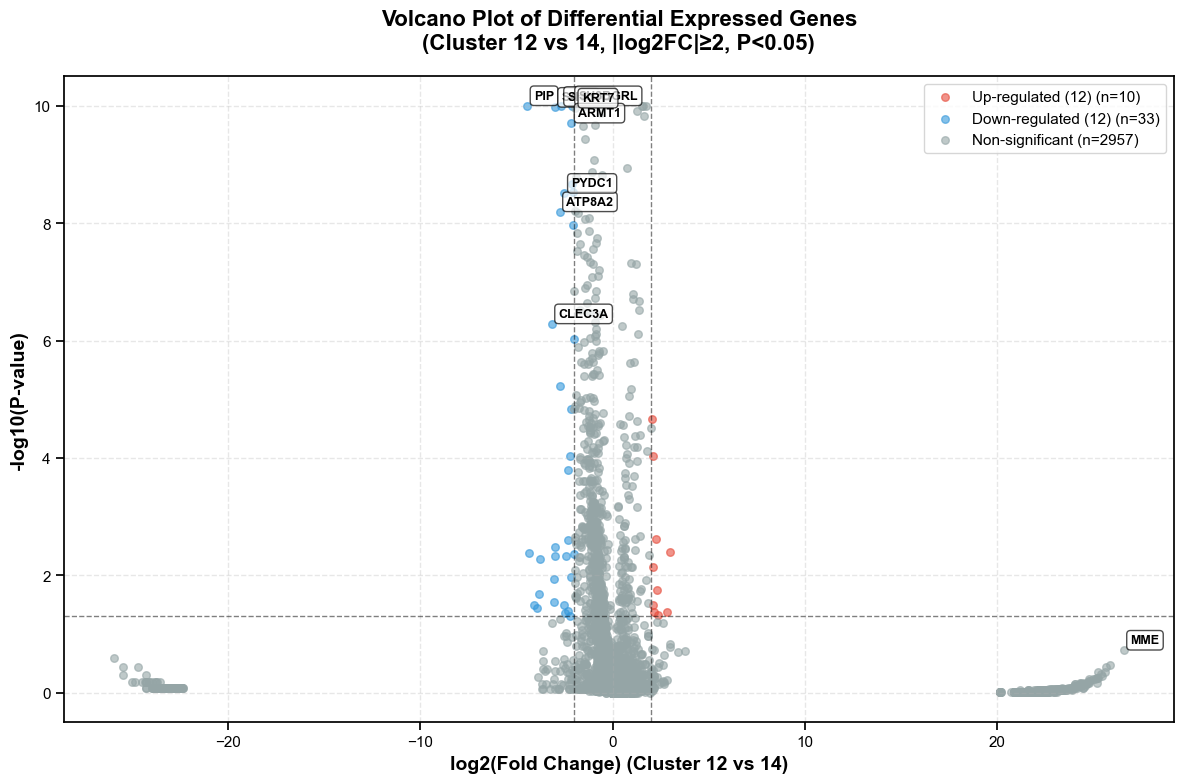

火山图统计：
12组显著上调基因数：10
12组显著下调基因数：33
不显著基因数：2957
✅ 火山图已保存为：cluster12_vs_14_volcano.pdf

进行GO富集分析（无依赖版，12 vs 14）
正在下载人类基因-GO映射文件（首次运行，约50MB）...
⚠️ GO富集分析出错：下载失败：HTTP Error 404: Not Found。请手动下载http://current.geneontology.org/annotations/hsa.gaf.gz并解压，再重新运行。
跳过GO富集分析，仅保留火山图结果

差异基因+火山图+GO富集分析（12 vs 14）全部完成！
生成的文件清单：
1. 火山图：cluster12_vs_14_volcano.pdf
2. GO富集结果（如有）：cluster12_vs_14_go_significant.csv
3. GO富集气泡图（如有）：cluster12_vs_14_go_bubble.pdf


In [22]:

# #     """
# #     """
    
    
# #     }
    
    
    
    
    
    
# #     )
    
    
    

# # )


# # try:

# #     """
# #     """
    
    
# #     )
    
    
# #     )
    
    
    

# #     """
# #     """
    
    
    
    
    
    
# #     )
    
# #     ]
    
    

    
# #     )
    
# # else:


#     args:
#         logfc_thresh: log2FCThreshold
#         pval_thresh: PValue threshold
#         save_path: Save path
    
    
#     }
    
    
#         ax.scatter(
#             de_df.loc[mask, 'logfoldchanges'],
#             de_df.loc[mask, 'neg_log10_p'],
#             c=color,
#             alpha=0.6,
#             s=30,
#         )
    
    
    
#         ax.annotate(
#             row['names'],
#             textcoords='offset points',
#             fontsize=9,
#             fontweight='bold',
#         )
    
#     ax.set_title(
#         fontsize=16, fontweight='bold', pad=20
#     )
    
    
#     # Save
    

# plot_volcano(
#     de_df=de_df,
#     logfc_thresh=logfc_thresh,
#     pval_thresh=pval_thresh,
#     save_path='cluster8_vs_12_volcano.pdf'
# )



#     try:
#             go_mapping_url,
#             sep='\t',
#             comment='!',  # Skip comment lines
#             header=None,
#             usecols=[1, 4, 8],  # Keep only gene symbols, GO IDs, GO categories
#             names=['gene_symbol', 'go_id', 'go_category']
#         )
#     except Exception as e:

#     try:
#     except FileNotFoundError:

#     try:
#             elif line == '':  # Entry end
#     except Exception as e:

#     args:
#         save_path_prefix: Save path prefix
#     return:
#         Enrichment resultDataFrame
    
    
    
    
    
        
#             continue  # no enrichment,Skip
        
        
        
#         enrichment_results.append({
#             'go_id': go_id,
#             'background_count': n,  # This in backgroundGOgene count
#             'significant_count': k,  # Among significant genes, thisGOgene count
#             'fold_enrichment': fe,
#             'p_val': p_val
#         })
    
    
    
    
    
    
    

#     Draw GO Enrichment bubble plot
#     args:
#         save_path: Save path
#         return
    
    
    
    
#             continue
#         ax.scatter(
#             top_go_df.loc[mask, 'neg_log10_adjp'],
#             top_go_df.loc[mask, 'go_term'],
#             s=sizes,
#             c=color,
#             alpha=0.7,
#             edgecolors='black',
#             linewidth=0.5,
#             label=cat_label[cat]
#         )
    
    
#     ax.set_title(
#         fontsize=16, fontweight='bold', pad=20
#     )
    
    
#     # Grid
    
#     # Save

    
#     try:
#             signif_genes=signif_gene_list,
#             save_path_prefix='cluster8_vs_12_go'
#         )
        
#             plot_go_bubble(
#                 go_results=go_results,
#                 save_path='cluster8_vs_12_go_bubble.pdf'
#             )
#     except Exception as e:
# else:

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy.stats import mannwhitneyu, hypergeom
import seaborn as sns
import requests

# --------------------------
# Basic settings
# --------------------------
cluster_key = 'domain'  # Clustering result column name
logfc_thresh = 2        # log2FC threshold
pval_thresh = 0.05      # P-value threshold
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.figsize'] = (12, 8)

# --------------------------
# Core fix: resolve log1p 'base' KeyError
# --------------------------
def fix_log1p_metadata(adata):
    if 'log1p' not in adata.uns:
        adata.uns['log1p'] = {}
    if 'base' not in adata.uns['log1p']:
        adata.uns['log1p']['base'] = None
    return adata

# --------------------------
# --------------------------
def get_rank_genes_groups_df_compat(adata, group):
    """
    Compatible with allScanpyVersion of differential gene extraction function
    First check dict type,Then checkrecarrayType,Avoid attribute error
    """
    rank_genes = adata.uns['rank_genes_groups']

    if isinstance(rank_genes, dict):
        genes = rank_genes['names'][group]
        logfc = rank_genes['logfoldchanges'][group]
        pvals = rank_genes['pvals'][group]
    else:  # recarrayType
        genes = rank_genes['names'][group]
        logfc = rank_genes['logfoldchanges'][group]
        pvals = rank_genes['pvals'][group]

    pvals_adj = np.full_like(genes, np.nan, dtype=float)  # Default fill with NaN
    if isinstance(rank_genes, dict):
        if 'pvals_adj' in rank_genes and group in rank_genes['pvals_adj']:
            pvals_adj = rank_genes['pvals_adj'][group]
    else:  # recarrayType
        if 'pvals_adj' in rank_genes.dtype.names:
            pvals_adj = rank_genes['pvals_adj'][group]

    # 3. Build DataFrame and clean invalid data
    de_df = pd.DataFrame({
        'names': genes,
        'logfoldchanges': logfc,
        'pvals': pvals,
        'pvals_adj': pvals_adj
    })
    de_df = de_df.dropna(subset=['names', 'logfoldchanges', 'pvals'])
    de_df['names'] = de_df['names'].astype(str)
    return de_df

# --------------------------
# --------------------------
adata = sc.read(os.path.join(REPO_ROOT, 'saved_results/dcpbst_adata_with_clusters.h5ad'))

print("=" * 60)
print("Start analysis:region 12 vs region 14")
print("=" * 60)

adata = fix_log1p_metadata(adata)

print("\nPerforming differential gene analysis (full dataset, 12 vs 14)...")
try:
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        groups=['12'],
        reference='14',
        method='wilcoxon',
        log2fc_min=logfc_thresh,
        use_raw=False
    )
    print("Differential gene analysis successful (use_raw=False)")
except Exception as e:
    print(f"use_raw=FalseFailed: {str(e)[:100]},Attemptuse_raw=True...")
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        groups=['12'],
        reference='14',
        method='wilcoxon',
        log2fc_min=logfc_thresh,
        use_raw=True
    )
    print("Differential gene analysis successful (use_raw=True)")

de_df = get_rank_genes_groups_df_compat(adata, group='12')

# --------------------------
# Step 2: Screen significant differential genes
# --------------------------
de_signif = de_df[
    (abs(de_df['logfoldchanges']) >= logfc_thresh) &
    (de_df['pvals'] < pval_thresh)
].sort_values('logfoldchanges', ascending=False).reset_index(drop=True)

print(f"\nDifferential gene statistics (cluster 12 vs cluster 14):{len(de_signif)}  significant differential genes")
print("Top 10 differential genes:")
print(de_signif[['names', 'logfoldchanges', 'pvals']].head(10))

# --------------------------
# --------------------------
print("\n" + "="*60)
print("Draw volcano plot of differential genes(12 vs 14)")
print("="*60)

def plot_volcano(de_df, logfc_thresh, pval_thresh, save_path):
    """
    Draw volcano plot(log2FC vs -log10(PValue))
    args:
        de_df: Differential gene resultsDataFrame(sc.get.rank_genes_groups_dfOutput)
        logfc_thresh: log2FCThreshold
        pval_thresh: PValue threshold
        save_path: Save path
    """
    de_df['neg_log10_p'] = -np.log10(de_df['pvals'] + 1e-10)
    
    de_df['category'] = 'Non-significant'
 de_df.loc[(de_df['logfoldchanges'] >= logfc_thresh) & (de_df['pvals'] < pval_thresh), 'category'] = 'Up-regulated (12)' # Modification:Clarify upregulation is12group
 de_df.loc[(de_df['logfoldchanges'] <= -logfc_thresh) & (de_df['pvals'] < pval_thresh), 'category'] = 'Down-regulated (12)' # Modification:Clarify downregulation is12group(i.e.14Group upregulated)
    
    # Set colors
    color_map = {
        'Up-regulated (12)': '#e74c3c',    # Red(12Group upregulated)
 'Down-regulated (12)': '# 3498db', # Blue(12groupDownregulated)
        'Non-significant': '#95a5a6'  # Gray(Not significant)
    }
    
    # Create canvas
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Draw scatter plot
    for cat, color in color_map.items():
        mask = de_df['category'] == cat
        ax.scatter(
            de_df.loc[mask, 'logfoldchanges'],
            de_df.loc[mask, 'neg_log10_p'],
            c=color,
            alpha=0.6,
            s=30,
            label=f'{cat} (n={mask.sum()})'
        )
    
    # Add threshold line
    ax.axvline(x=logfc_thresh, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=-logfc_thresh, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(y=-np.log10(pval_thresh), color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    de_df['score'] = abs(de_df['logfoldchanges']) * de_df['neg_log10_p']
    top_genes = de_df.nlargest(10, 'score')
    
    for _, row in top_genes.iterrows():
        ax.annotate(
            row['names'],
            xy=(row['logfoldchanges'], row['neg_log10_p']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
        )
    
    ax.set_xlabel('log2(Fold Change) (Cluster 12 vs 14)', fontsize=14, fontweight='bold')
    ax.set_ylabel('-log10(P-value)', fontsize=14, fontweight='bold')
    ax.set_title(
        f'Volcano Plot of Differential Expressed Genes\n(Cluster 12 vs 14, |log2FC|≥{logfc_thresh}, P<{pval_thresh})',
        fontsize=16, fontweight='bold', pad=20
    )
    
    # Legend、Grid
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Save
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    
    # Output statistics
    print(f"Volcano plot statistics:")
 print(f"12groupCount of significantly upregulated genes:{sum(de_df['category'] == 'Up-regulated (12)')}")
 print(f"12groupCount of significantly downregulated genes:{sum(de_df['category'] == 'Down-regulated (12)')}")
    print(f"Count of non-significant genes:{sum(de_df['category'] == 'Non-significant')}")

plot_volcano(
    de_df=de_df,
    logfc_thresh=logfc_thresh,
    pval_thresh=pval_thresh,
    save_path='cluster12_vs_14_volcano.pdf'
)
print("✅ Volcano plot saved as:cluster12_vs_14_volcano.pdf")

# --------------------------
# --------------------------
print("\n" + "="*60)
print("Perform GO enrichment analysis (no-dependency version, 12 vs 14)")
print("="*60)

def download_go_mapping():
 """Download human gene-GO term mapping file(from geneontology.org,authoritative and reliable)"""
    go_mapping_url = "http://current.geneontology.org/annotations/hsa.gaf.gz"
    try:
 print("Downloading human gene-GO mapping file(first run,approx.50MB)...")
        go_df = pd.read_csv(
            go_mapping_url,
            sep='\t',
            comment='!',  # Skip comment lines
            header=None,
            usecols=[1, 4, 8],  # Keep only gene symbols, GO IDs, GO categories
            names=['gene_symbol', 'go_id', 'go_category']
        )
        # Filter invalid data
        go_df = go_df.dropna()
        go_df = go_df[go_df['go_category'].isin(['P', 'C', 'F'])]  # P=BP, C=CC, F=MF
        # Convert category names
        go_df['go_category'] = go_df['go_category'].map({'P': 'BP', 'C': 'CC', 'F': 'MF'})
        go_df.to_csv('hsa_go_mapping.csv', index=False)
        print("GO mapping file downloaded and saved as:hsa_go_mapping.csv")
        return go_df
    except Exception as e:
 raise Exception(f"Download failed:{str(e)}。Please download manuallyhttp://current.geneontology.org/annotations/hsa.gaf.gzand decompress,then re-run。")

def load_go_mapping():
 """Loadgene-GO mapping file(Prefer local, download if not exists,download if not exists)"""
    try:
        # Try to read local file
        go_df = pd.read_csv('hsa_go_mapping.csv')
 print("Successfully loaded local GO mapping file")
    except FileNotFoundError:
        # No local file, downloading
        go_df = download_go_mapping()
    return go_df

def load_go_terms():
 """LoadGO term namefile(GO ID→Term name)"""
    go_term_url = "http://purl.obolibrary.org/obo/go/go-basic.obo"
    go_terms = {}
    try:
        print("Loading GO term names...")
        response = requests.get(go_term_url, stream=True)
        response.raise_for_status()
        current_id = None
        current_name = None
        for line in response.iter_lines(decode_unicode=True):
            if line.startswith('id: GO:'):
                current_id = line.split(' ')[1]
            elif line.startswith('name: '):
                current_name = line[6:].strip()
            elif line == '':  # Entry end
                if current_id and current_name:
                    go_terms[current_id] = current_name
                current_id = None
                current_name = None
 print(f"Successfully loaded {len(go_terms)} GO term")
        return go_terms
    except Exception as e:
        raise Exception(f"Failed to load GO terms:{str(e)}")

def run_go_enrichment(signif_genes, save_path_prefix='go_enrichment'):
    """
 No-dependency GO enrichment analysis(Hypergeometric test)
    args:
 signif_genes: Significant differential gene list(gene symbols)
        save_path_prefix: Save path prefix
    return:
        Enrichment resultDataFrame
    """
    if len(signif_genes) == 0:
        raise ValueError("No significant differential genes, cannot perform GO enrichment analysis!")
    
    # Load gene-GO mapping and GO term names
    go_mapping = load_go_mapping()
    go_terms = load_go_terms()
    
    background_genes = set(go_mapping['gene_symbol'].unique())
    print(f"Background gene count (with GO annotation):{len(background_genes)}")
    print(f"Significant differential gene count:{len(signif_genes)}")
    
    # 2. Screen significant genes present inGOAnnotated genes
    signif_genes_with_go = [g for g in signif_genes if g in background_genes]
    if len(signif_genes_with_go) == 0:
 raise ValueError("No significant differential genes have GO annotation, cannot perform enrichment analysis!")
    print(f"Significant differential gene count with GO annotation:{len(signif_genes_with_go)}")
    
    # 3. ByGO IDGroup,Calculate for eachGOenrichment status
    go_groups = go_mapping.groupby('go_id')
    enrichment_results = []
    
    print("Performing hypergeometric test...")
    for go_id, group in go_groups:
        go_background_genes = set(group['gene_symbol'].unique())
        M = len(background_genes)
        n = len(go_background_genes)  # This in backgroundGOgene count
        N = len(signif_genes_with_go)  # Among significant genes there areGOnumber of annotations
        k = len(go_background_genes & set(signif_genes_with_go))  # Among significant genes belonging to thisGOnumber of
        
        if k == 0:
            continue  # no enrichment,Skip
        
        p_val = hypergeom.sf(k-1, M, n, N)
        
        fe = (k / N) / (n / M)
        
        # Collect results
        enrichment_results.append({
            'go_id': go_id,
            'go_term': go_terms.get(go_id, 'Unknown'),
            'go_category': group['go_category'].iloc[0],  # ThisGOcategories(BP/CC/MF)
            'background_count': n,  # This in backgroundGOgene count
            'significant_count': k,  # Among significant genes, thisGOgene count
            'fold_enrichment': fe,
            'p_val': p_val
        })
    
    results_df = pd.DataFrame(enrichment_results)
    if results_df.empty:
        print("No enriched GO terms found!")
        return None
    
    # Benjamini-HochbergCorrect
    results_df = results_df.sort_values('p_val')
    results_df['adj_p_val'] = results_df['p_val'] * len(results_df) / np.arange(1, len(results_df)+1)
    results_df['adj_p_val'] = results_df['adj_p_val'].clip(upper=1.0)  # Adjusted P-value does not exceed 1
    
    significant_go = results_df[results_df['adj_p_val'] < 0.05].copy()
    if significant_go.empty:
 print("No significantly enriched GO terms found(adj_p_val < 0.05)!")
        return None
    
    cat_label = {'BP': 'Biological Process', 'CC': 'Cellular Component', 'MF': 'Molecular Function'}
    significant_go['go_category_name'] = significant_go['go_category'].map(cat_label)
    significant_go['neg_log10_adjp'] = -np.log10(significant_go['adj_p_val'])
    
    significant_go.to_csv(f'{save_path_prefix}_significant.csv', index=False)
    results_df.to_csv(f'{save_path_prefix}_all_results.csv', index=False)
    
    print(f"Significantly enriched GO term count:{len(significant_go)}")
    print(f"GO-BP: {len(significant_go[significant_go['go_category']=='BP'])} ")
    print(f"GO-CC: {len(significant_go[significant_go['go_category']=='CC'])} ")
    print(f"GO-MF: {len(significant_go[significant_go['go_category']=='MF'])} ")
    
    return significant_go

def plot_go_bubble(go_results, save_path):
    """
    Draw GO Enrichment bubble plot
    args:
        go_results: Enrichment resultDataFrame(run_go_enrichmentOutput)
        save_path: Save path
    """
    if go_results is None or go_results.empty:
        print("No significant enrichment results,Cannot draw bubble plot!")
        return
    
    # Sort by GO category and enrichment significance, take Top10 terms per category
    top_go = []
    for cat in ['BP', 'CC', 'MF']:
        cat_data = go_results[go_results['go_category'] == cat].copy()
        if len(cat_data) > 0:
            cat_data = cat_data.nlargest(min(10, len(cat_data)), 'neg_log10_adjp')
            top_go.append(cat_data)
    top_go_df = pd.concat(top_go, ignore_index=True)
    
    # Set colors and labels
    cat_color = {'BP': '#e74c3c', 'CC': '#3498db', 'MF': '#2ecc71'}
    cat_label = {'BP': 'Biological Process', 'CC': 'Cellular Component', 'MF': 'Molecular Function'}
    
    # Create canvas
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Draw bubble plot
    for cat, color in cat_color.items():
        mask = top_go_df['go_category'] == cat
        if mask.sum() == 0:
            continue
        sizes = top_go_df.loc[mask, 'significant_count'] * 15
        ax.scatter(
            top_go_df.loc[mask, 'neg_log10_adjp'],
            top_go_df.loc[mask, 'go_term'],
            s=sizes,
            c=color,
            alpha=0.7,
            edgecolors='black',
            linewidth=0.5,
            label=cat_label[cat]
        )
    
    ax.axvline(x=-np.log10(0.05), color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('-log10(Adjusted P-value)', fontsize=14, fontweight='bold')
    ax.set_ylabel('GO Terms', fontsize=14, fontweight='bold')
    ax.set_title(
        f'GO Enrichment Analysis (Cluster 12 vs 14)\nTop 10 Terms per Category',
        fontsize=16, fontweight='bold', pad=20
    )
    
    import matplotlib.patches as mpatches
    cat_legend = [mpatches.Patch(color=c, alpha=0.7, label=l) for c, l in cat_label.items()]
    size_legend = [mpatches.Patch(color='gray', alpha=0.7, label=f'{n} genes') for n in [2, 5, 10, 20]]
    ax.legend(handles=cat_legend + size_legend, loc='upper right', fontsize=10)
    
    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Save
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

if len(de_signif) > 0:
    signif_gene_list = de_signif['names'].tolist()
    
    try:
        go_results = run_go_enrichment(
            signif_genes=signif_gene_list,
            save_path_prefix='cluster12_vs_14_go'
        )
        
        if go_results is not None and not go_results.empty:
            plot_go_bubble(
                go_results=go_results,
                save_path='cluster12_vs_14_go_bubble.pdf'
            )
            print("✅ GO enrichment bubble plot saved as:cluster12_vs_14_go_bubble.pdf")
    except Exception as e:
        print(f"Warning GO enrichment analysis error:{str(e)}")
        print("SkipGO Enrichment analysis,Keep only volcano plot results")
else:
    print("Warning  No significant differential genes, skip GO enrichment analysis!")

print("\n" + "="*60)
print("Differential genes+Volcano plot+GO Enrichment analysis(12 vs 14)All completed!")
print("="*60)
print("Generated file list:")
print("1. Volcano plot:cluster12_vs_14_volcano.pdf")
print("2. GO Enrichment result(If exists):cluster12_vs_14_go_significant.csv")
print("3. GO Enrichment bubble plot(If exists):cluster12_vs_14_go_bubble.pdf")

开始分析：区域12 vs 区域14（以14组为基准）

正在进行差异基因分析（全量数据集，12 vs 14）...
差异基因分析成功（use_raw=False）

差异基因统计（以14组为基准）：
14组显著上调基因数：33
14组显著下调基因数：10
总显著差异基因数：43

14组前5个最显著上调基因（按P值排序）：
     names  logfoldchanges         pvals
0      PIP       -4.451593  1.612555e-13
1  SH3BGRL       -2.135345  5.301232e-13
2   SHISA2       -2.707044  3.171480e-12
3     SAA1       -3.018519  6.737278e-12
4    ARMT1       -2.159059  9.811644e-11

绘制差异基因火山图（以14组为基准，标注前5个最显著上调基因）

将标注14组前5个最显著上调基因：['PIP', 'SH3BGRL', 'SHISA2', 'SAA1', 'ARMT1']


/root/miniconda3/envs/miso/lib/python3.7/site-packages/ipykernel_launcher.py:52: FutureWarning: elementwise == comparison failed and returning scalar instead; this will raise an error or perform elementwise comparison in the future.


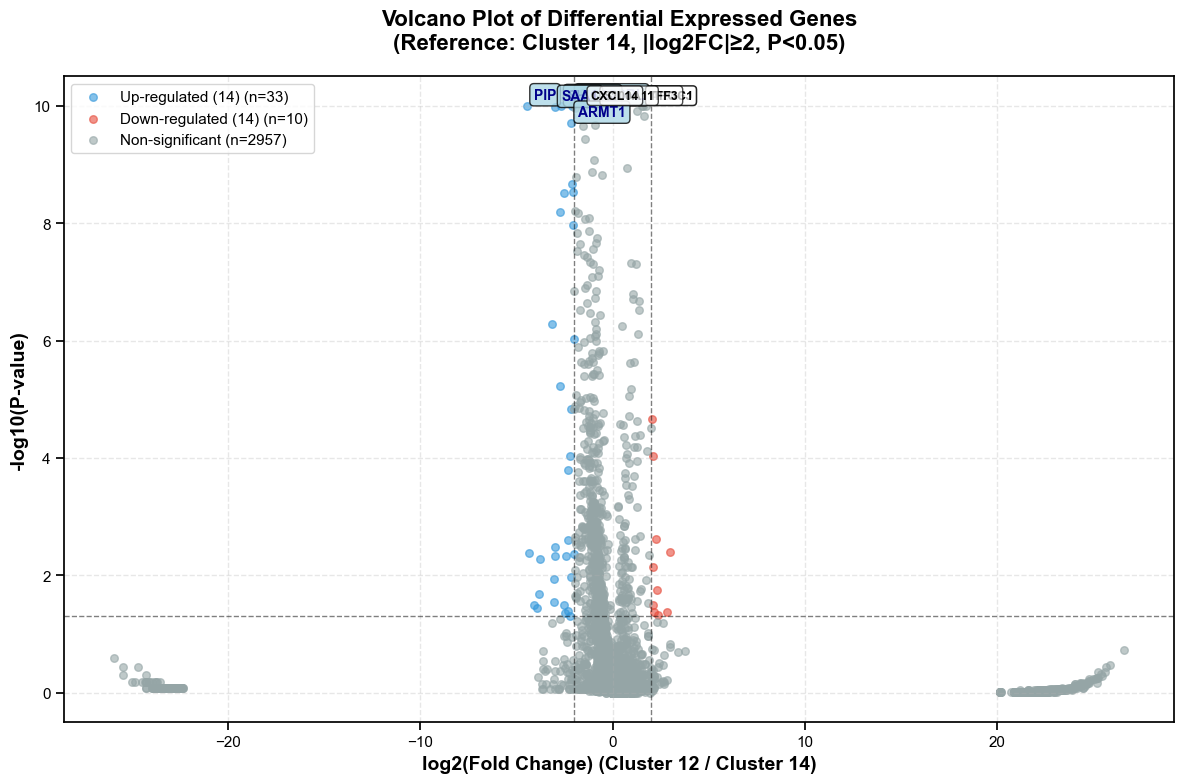


火山图统计（以14组为基准）：
14组显著上调基因数：33
14组显著下调基因数：10
不显著基因数：2957
✅ 以14组为基准的火山图已保存为：cluster12_vs_14_volcano_14_based.pdf

进行GO富集分析（无依赖版，基于14组显著差异基因）
正在下载人类基因-GO映射文件（首次运行，约50MB）...
⚠️ GO富集分析出错：下载失败：HTTP Error 404: Not Found。请手动下载http://current.geneontology.org/annotations/hsa.gaf.gz并解压，再重新运行。
跳过GO富集分析，仅保留火山图结果

差异基因+火山图（14组为基准）+GO富集分析 全部完成！
生成的文件清单：
1. 火山图（14组为基准）：cluster12_vs_14_volcano_14_based.pdf
2. GO富集结果（14组为基准，如有）：cluster12_vs_14_go_14_based_significant.csv
3. GO富集气泡图（14组为基准，如有）：cluster12_vs_14_go_bubble_14_based.pdf


In [23]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy.stats import mannwhitneyu, hypergeom
import seaborn as sns
import requests

# --------------------------
# Basic settings
# --------------------------
cluster_key = 'domain'  # Clustering result column name
logfc_thresh = 2        # log2FC threshold
pval_thresh = 0.05      # P-value threshold
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.figsize'] = (12, 8)

# --------------------------
# Core fix: resolve log1p 'base' KeyError
# --------------------------
def fix_log1p_metadata(adata):
    if 'log1p' not in adata.uns:
        adata.uns['log1p'] = {}
    if 'base' not in adata.uns['log1p']:
        adata.uns['log1p']['base'] = None
    return adata

# --------------------------
# --------------------------
def get_rank_genes_groups_df_compat(adata, group):
    """
    Compatible with allScanpyVersion of differential gene extraction function
    First check dict type,Then checkrecarrayType,Avoid attribute error
    """
    rank_genes = adata.uns['rank_genes_groups']

    if isinstance(rank_genes, dict):
        genes = rank_genes['names'][group]
        logfc = rank_genes['logfoldchanges'][group]
        pvals = rank_genes['pvals'][group]
    else:  # recarrayType
        genes = rank_genes['names'][group]
        logfc = rank_genes['logfoldchanges'][group]
        pvals = rank_genes['pvals'][group]

    pvals_adj = np.full_like(genes, np.nan, dtype=float)  # Default fill with NaN
    if isinstance(rank_genes, dict):
        if 'pvals_adj' in rank_genes and group in rank_genes['pvals_adj']:
            pvals_adj = rank_genes['pvals_adj'][group]
    else:  # recarrayType
        if 'pvals_adj' in rank_genes.dtype.names:
            pvals_adj = rank_genes['pvals_adj'][group]

    # 3. Build DataFrame and clean invalid data
    de_df = pd.DataFrame({
        'names': genes,
        'logfoldchanges': logfc,
        'pvals': pvals,
        'pvals_adj': pvals_adj
    })
    de_df = de_df.dropna(subset=['names', 'logfoldchanges', 'pvals'])
    de_df['names'] = de_df['names'].astype(str)
    return de_df

# --------------------------
# --------------------------
adata = sc.read(os.path.join(REPO_ROOT, 'saved_results/dcpbst_adata_with_clusters.h5ad'))

print("=" * 60)
print("Start analysis:region 12 vs region 14(As14Based on group)")
print("=" * 60)

adata = fix_log1p_metadata(adata)

print("\nPerforming differential gene analysis (full dataset, 12 vs 14)...")
try:
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        groups=['12'],
 reference='14', # reference groupas14,log2FC = 12Group expression / 14Group expression
        method='wilcoxon',
        log2fc_min=logfc_thresh,
        use_raw=False
    )
    print("Differential gene analysis successful (use_raw=False)")
except Exception as e:
    print(f"use_raw=FalseFailed: {str(e)[:100]},Attemptuse_raw=True...")
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        groups=['12'],
        reference='14',
        method='wilcoxon',
        log2fc_min=logfc_thresh,
        use_raw=True
    )
    print("Differential gene analysis successful (use_raw=True)")

de_df = get_rank_genes_groups_df_compat(adata, group='12')

# --------------------------
# --------------------------
de_signif_14_up = de_df[
    (de_df['logfoldchanges'] <= -logfc_thresh) &  
    (de_df['pvals'] < pval_thresh)
].sort_values('pvals', ascending=True).reset_index(drop=True)  # Ascending by P-value (smaller is more significant)

de_signif_14_down = de_df[
    (de_df['logfoldchanges'] >= logfc_thresh) &  
    (de_df['pvals'] < pval_thresh)
].sort_values('pvals', ascending=True).reset_index(drop=True)

de_signif = pd.concat([de_signif_14_up, de_signif_14_down], ignore_index=True)

print(f"\nDifferential gene statistics(As14Based on group):")
print(f"14groupCount of significantly upregulated genes:{len(de_signif_14_up)}")
print(f"14groupCount of significantly downregulated genes:{len(de_signif_14_down)}")
print(f"Total significant differential gene count: {len(de_signif)}")
print("\n14Before group5Most significantly upregulated genes(ByPSort by value):")
if len(de_signif_14_up) >= 5:
    print(de_signif_14_up[['names', 'logfoldchanges', 'pvals']].head(5))
else:
    print(de_signif_14_up[['names', 'logfoldchanges', 'pvals']])
 print(f"Warning 14Group upregulatedGenenot sufficient5,WillAllAnnotation")

# --------------------------
# --------------------------
print("\n" + "="*60)
print("Draw volcano plot of differential genes(As14Based on group,Before annotation5Most significantly upregulated genes)")
print("="*60)

def plot_volcano_14_based(de_df, logfc_thresh, pval_thresh, save_path, top_n_up=5):
    """
    Draw volcano plot(As14Based on group)
    args:
        de_df: Differential gene resultsDataFrame
        logfc_thresh: log2FCThreshold
        pval_thresh: PValue threshold
        save_path: Save path
 top_n_up: Annotation14Before groupNMost significantly upregulated genes(default5)
    """
    de_df['neg_log10_p'] = -np.log10(de_df['pvals'] + 1e-10)
    
    de_df['category'] = 'Non-significant'
    de_df.loc[(de_df['logfoldchanges'] <= -logfc_thresh) & (de_df['pvals'] < pval_thresh), 'category'] = 'Up-regulated (14)'
    de_df.loc[(de_df['logfoldchanges'] >= logfc_thresh) & (de_df['pvals'] < pval_thresh), 'category'] = 'Down-regulated (14)'
    
    # Set colors
    color_map = {
        'Up-regulated (14)': '#3498db',    # Blue(14Group upregulated)
 'Down-regulated (14)': '# e74c3c', # Red(14groupDownregulated)
        'Non-significant': '#95a5a6'       # Gray(Not significant)
    }
    
    # Create canvas
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Draw scatter plot
    for cat, color in color_map.items():
        mask = de_df['category'] == cat
        ax.scatter(
            de_df.loc[mask, 'logfoldchanges'],
            de_df.loc[mask, 'neg_log10_p'],
            c=color,
            alpha=0.6,
            s=30,
            label=f'{cat} (n={mask.sum()})'
        )
    
    # Add threshold line
    ax.axvline(x=logfc_thresh, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=-logfc_thresh, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(y=-np.log10(pval_thresh), color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    significant_14_up = de_df[de_df['category'] == 'Up-regulated (14)'].sort_values('pvals', ascending=True)
 top_14_up_genes = significant_14_up.head(top_n_up) # TaketopNmost significant
    
    print(f"\nWillAnnotation14Before group{len(top_14_up_genes)}Most significantly upregulated genes:{top_14_up_genes['names'].tolist()}")
    
    for _, row in top_14_up_genes.iterrows():
        ax.annotate(
            row['names'],
            xy=(row['logfoldchanges'], row['neg_log10_p']),
            xytext=(5, 5),  # Text offset
            textcoords='offset points',
            fontsize=10,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.8),  # Blue background highlight
            color='darkblue'
        )
    
    other_significant = de_df[de_df['category'] != 'Up-regulated (14)'].sort_values('neg_log10_p', ascending=False)
 top_other_genes = other_significant.head(5) # Annotate 5 other significant genes
    
    for _, row in top_other_genes.iterrows():
        ax.annotate(
            row['names'],
            xy=(row['logfoldchanges'], row['neg_log10_p']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
        )
    
    # Set axis labels and title
    ax.set_xlabel('log2(Fold Change) (Cluster 12 / Cluster 14)', fontsize=14, fontweight='bold')
    ax.set_ylabel('-log10(P-value)', fontsize=14, fontweight='bold')
    ax.set_title(
        f'Volcano Plot of Differential Expressed Genes\n(Reference: Cluster 14, |log2FC|≥{logfc_thresh}, P<{pval_thresh})',
        fontsize=16, fontweight='bold', pad=20
    )
    
    # Legend、Grid
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Save
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    
    # Output statistics
 print(f"\nVolcano plotStatistics(As14Based on group):")
 print(f"14groupCount of significantly upregulated genes:{sum(de_df['category'] == 'Up-regulated (14)')}")
 print(f"14groupCount of significantly downregulated genes:{sum(de_df['category'] == 'Down-regulated (14)')}")
    print(f"Count of non-significant genes:{sum(de_df['category'] == 'Non-significant')}")

plot_volcano_14_based(
    de_df=de_df,
    logfc_thresh=logfc_thresh,
    pval_thresh=pval_thresh,
    save_path='cluster12_vs_14_volcano_14_based.pdf',
    top_n_up=5  # Can adjust annotation count(# IfChange to3or10)
)
print("✅ As14Based on groupVolcano plot saved as:cluster12_vs_14_volcano_14_based.pdf")

# --------------------------
# --------------------------
print("\n" + "="*60)
print("PerformGO enrichment analysis(no-dependency version,Based on14Group significant differential genes)")
print("="*60)

def download_go_mapping():
 """Download human gene-GO term mapping file(from geneontology.org,authoritative and reliable)"""
    go_mapping_url = "http://current.geneontology.org/annotations/hsa.gaf.gz"
    try:
 print("Downloading human gene-GO mapping file(first run,approx.50MB)...")
        go_df = pd.read_csv(
            go_mapping_url,
            sep='\t',
            comment='!',  # Skip comment lines
            header=None,
            usecols=[1, 4, 8],  # Keep only gene symbols, GO IDs, GO categories
            names=['gene_symbol', 'go_id', 'go_category']
        )
        go_df = go_df.dropna()
        go_df = go_df[go_df['go_category'].isin(['P', 'C', 'F'])]  # P=BP, C=CC, F=MF
        go_df['go_category'] = go_df['go_category'].map({'P': 'BP', 'C': 'CC', 'F': 'MF'})
        go_df.to_csv('hsa_go_mapping.csv', index=False)
        print("GO mapping file downloaded and saved as:hsa_go_mapping.csv")
        return go_df
    except Exception as e:
 raise Exception(f"Download failed:{str(e)}。Please download manuallyhttp://current.geneontology.org/annotations/hsa.gaf.gzand decompress,then re-run。")

def load_go_mapping():
 """Loadgene-GO mapping file(Prefer local, download if not exists,download if not exists)"""
    try:
        go_df = pd.read_csv('hsa_go_mapping.csv')
 print("Successfully loaded local GO mapping file")
    except FileNotFoundError:
        go_df = download_go_mapping()
    return go_df

def load_go_terms():
 """LoadGO term namefile(GO ID→Term name)"""
    go_term_url = "http://purl.obolibrary.org/obo/go/go-basic.obo"
    go_terms = {}
    try:
        print("Loading GO term names...")
        response = requests.get(go_term_url, stream=True)
        response.raise_for_status()
        current_id = None
        current_name = None
        for line in response.iter_lines(decode_unicode=True):
            if line.startswith('id: GO:'):
                current_id = line.split(' ')[1]
            elif line.startswith('name: '):
                current_name = line[6:].strip()
            elif line == '':  # Entry end
                if current_id and current_name:
                    go_terms[current_id] = current_name
                current_id = None
                current_name = None
 print(f"Successfully loaded {len(go_terms)} GO term")
        return go_terms
    except Exception as e:
        raise Exception(f"Failed to load GO terms:{str(e)}")

def run_go_enrichment(signif_genes, save_path_prefix='go_enrichment'):
    """
 No-dependency GO enrichment analysis(Hypergeometric test)
    args:
 signif_genes: Significant differential gene list(gene symbols)
        save_path_prefix: Save path prefix
    return:
        Enrichment resultDataFrame
    """
    if len(signif_genes) == 0:
        raise ValueError("No significant differential genes, cannot perform GO enrichment analysis!")
    
    go_mapping = load_go_mapping()
    go_terms = load_go_terms()
    
    background_genes = set(go_mapping['gene_symbol'].unique())
    print(f"Background gene count (with GO annotation):{len(background_genes)}")
    print(f"Significant differential gene count:{len(signif_genes)}")
    
    signif_genes_with_go = [g for g in signif_genes if g in background_genes]
    if len(signif_genes_with_go) == 0:
 raise ValueError("No significant differential genes have GO annotation, cannot perform enrichment analysis!")
    print(f"Significant differential gene count with GO annotation:{len(signif_genes_with_go)}")
    
    go_groups = go_mapping.groupby('go_id')
    enrichment_results = []
    
    print("Performing hypergeometric test...")
    for go_id, group in go_groups:
        go_background_genes = set(group['gene_symbol'].unique())
        M = len(background_genes)
        n = len(go_background_genes)
        N = len(signif_genes_with_go)
        k = len(go_background_genes & set(signif_genes_with_go))
        
        if k == 0:
            continue
        
        p_val = hypergeom.sf(k-1, M, n, N)
        fe = (k / N) / (n / M)
        
        enrichment_results.append({
            'go_id': go_id,
            'go_term': go_terms.get(go_id, 'Unknown'),
            'go_category': group['go_category'].iloc[0],
            'background_count': n,
            'significant_count': k,
            'fold_enrichment': fe,
            'p_val': p_val
        })
    
    results_df = pd.DataFrame(enrichment_results)
    if results_df.empty:
        print("No enriched GO terms found!")
        return None
    
    results_df = results_df.sort_values('p_val')
    results_df['adj_p_val'] = results_df['p_val'] * len(results_df) / np.arange(1, len(results_df)+1)
    results_df['adj_p_val'] = results_df['adj_p_val'].clip(upper=1.0)
    
    significant_go = results_df[results_df['adj_p_val'] < 0.05].copy()
    if significant_go.empty:
 print("No significantly enriched GO terms found(adj_p_val < 0.05)!")
        return None
    
    cat_label = {'BP': 'Biological Process', 'CC': 'Cellular Component', 'MF': 'Molecular Function'}
    significant_go['go_category_name'] = significant_go['go_category'].map(cat_label)
    significant_go['neg_log10_adjp'] = -np.log10(significant_go['adj_p_val'])
    
    significant_go.to_csv(f'{save_path_prefix}_significant.csv', index=False)
    results_df.to_csv(f'{save_path_prefix}_all_results.csv', index=False)
    
    print(f"Significantly enriched GO term count:{len(significant_go)}")
    print(f"GO-BP: {len(significant_go[significant_go['go_category']=='BP'])} ")
    print(f"GO-CC: {len(significant_go[significant_go['go_category']=='CC'])} ")
    print(f"GO-MF: {len(significant_go[significant_go['go_category']=='MF'])} ")
    
    return significant_go

def plot_go_bubble(go_results, save_path, title_suffix=""):
    """
    Draw GO Enrichment bubble plot
    args:
        go_results: Enrichment resultDataFrame
        save_path: Save path
 title_suffix: Title suffix (annotation reference group)
    """
    if go_results is None or go_results.empty:
        print("No significant enrichment results,Cannot draw bubble plot!")
        return
    
    top_go = []
    for cat in ['BP', 'CC', 'MF']:
        cat_data = go_results[go_results['go_category'] == cat].copy()
        if len(cat_data) > 0:
            cat_data = cat_data.nlargest(min(10, len(cat_data)), 'neg_log10_adjp')
            top_go.append(cat_data)
    top_go_df = pd.concat(top_go, ignore_index=True)
    
    cat_color = {'BP': '#e74c3c', 'CC': '#3498db', 'MF': '#2ecc71'}
    cat_label = {'BP': 'Biological Process', 'CC': 'Cellular Component', 'MF': 'Molecular Function'}
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    for cat, color in cat_color.items():
        mask = top_go_df['go_category'] == cat
        if mask.sum() == 0:
            continue
        sizes = top_go_df.loc[mask, 'significant_count'] * 15
        ax.scatter(
            top_go_df.loc[mask, 'neg_log10_adjp'],
            top_go_df.loc[mask, 'go_term'],
            s=sizes,
            c=color,
            alpha=0.7,
            edgecolors='black',
            linewidth=0.5,
            label=cat_label[cat]
        )
    
    ax.axvline(x=-np.log10(0.05), color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('-log10(Adjusted P-value)', fontsize=14, fontweight='bold')
    ax.set_ylabel('GO Terms', fontsize=14, fontweight='bold')
    ax.set_title(
        f'GO Enrichment Analysis (Cluster 12 vs 14, Reference: Cluster 14){title_suffix}\nTop 10 Terms per Category',
        fontsize=16, fontweight='bold', pad=20
    )
    
    import matplotlib.patches as mpatches
    cat_legend = [mpatches.Patch(color=c, alpha=0.7, label=l) for c, l in cat_label.items()]
    size_legend = [mpatches.Patch(color='gray', alpha=0.7, label=f'{n} genes') for n in [2, 5, 10, 20]]
    ax.legend(handles=cat_legend + size_legend, loc='upper right', fontsize=10)
    
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

if len(de_signif) > 0:
    signif_gene_list = de_signif['names'].tolist()
    
    try:
        go_results = run_go_enrichment(
            signif_genes=signif_gene_list,
            save_path_prefix='cluster12_vs_14_go_14_based'
        )
        
        if go_results is not None and not go_results.empty:
            plot_go_bubble(
                go_results=go_results,
                save_path='cluster12_vs_14_go_bubble_14_based.pdf',
                title_suffix=' (14Based on group)'
            )
            print("✅ As14Based on groupGO enrichment bubble plot saved as:cluster12_vs_14_go_bubble_14_based.pdf")
    except Exception as e:
        print(f"Warning GO enrichment analysis error:{str(e)}")
        print("SkipGO Enrichment analysis,Keep only volcano plot results")
else:
    print("Warning  No significant differential genes, skip GO enrichment analysis!")

print("\n" + "="*60)
print("Differential genes+Volcano plot(14Based on group)+GO Enrichment analysis All completed!")
print("="*60)
print("Generated file list:")
print("1. Volcano plot(14Based on group):cluster12_vs_14_volcano_14_based.pdf")
print("2. GO Enrichment result(14Based on group,If exists):cluster12_vs_14_go_14_based_significant.csv")
print("3. GO Enrichment bubble plot(14Based on group,If exists):cluster12_vs_14_go_bubble_14_based.pdf")